# ⚽ Football Player Performance Analytics
## A Complete Data Science Pipeline — Season 2023/24

---

**Pipeline stages covered in this notebook:**

| # | Stage | Description |
|---|-------|-------------|
| 1 | Data Ingestion | Load raw Excel file, inspect shape & schema |
| 2 | Data Quality Audit | Detect nulls, duplicates, outliers, type mismatches |
| 3 | Data Cleaning | Fix every issue found in the audit |
| 4 | Feature Engineering | Derive new analytical metrics |
| 5 | Exploratory Data Analysis (EDA) | Statistical summaries & visualizations |
| 6 | Advanced Visualizations | Heatmaps, radar charts, scatter plots |

> **Dataset:** `football_players_UNCLEAN.xlsx` — 40 top-tier players with real-world data quality issues intentionally embedded.

---

## 0 · Setup & Imports

In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Data ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

# ── Plot aesthetics ───────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

PALETTE = ['#1A3C5E','#E8473F','#2ECC71','#F39C12','#9B59B6','#1ABC9C']
sns.set_palette(PALETTE)

print('All libraries imported successfully.')

All libraries imported successfully.


In [39]:
# ── Create directory for plots ────────────────────────────────────────────────
import os

PLOTS_DIR = 'plots'
if not os.path.exists(PLOTS_DIR):
    os.makedirs(PLOTS_DIR)
    print(f'Created directory: {PLOTS_DIR}')
else:
    print(f'Directory already exists: {PLOTS_DIR}')

Created directory: plots


---
## 1 · Data Ingestion

We load the raw Excel file exactly as delivered — no transformations yet. The goal is to see the data as it truly is.

In [3]:
# ── Load ──────────────────────────────────────────────────────────────────────
FILE_PATH = 'football_players_UNCLEAN.xlsx'   # adjust path if needed

df_raw = pd.read_excel(
    FILE_PATH,
    sheet_name='PlayerStats_RAW',
    header=2,       # row 3 (0-indexed: 2) contains column headers
    nrows=50        # read extra rows — we'll drop trailing metadata later
)

print(f'Shape (raw): {df_raw.shape}')
print(f'Columns ({len(df_raw.columns)}): {list(df_raw.columns)}')

Shape (raw): (45, 23)
Columns (23): ['Player Name', 'Nationality', 'Position ', 'Club', 'Age', 'Height(m)', 'Weight(kg)', 'Apps', 'Goals', 'Assists', 'Shots', 'ShotsOnTarget', 'passes_total', 'Pass Accuracy%', 'Dribbles', 'Tackles', 'Interceptions', 'Yellow Cards', 'Red Cards', 'Minutes Played', 'Avg Rating', 'Market Value(M€)', 'Weekly Wage(K€)']


In [4]:
# ── Preview ───────────────────────────────────────────────────────────────────
df_raw.head(10)

,Player Name,Nationality,Position,Club,Age,Height(m),Weight(kg),Apps,Goals,Assists,...,Pass Accuracy%,Dribbles,Tackles,Interceptions,Yellow Cards,Red Cards,Minutes Played,Avg Rating,Market Value(M€),Weekly Wage(K€)
0,Lionel Messi,Argentina,Forward,Inter Miami,37,1.70,NaN,38.0,21.0,6.0,...,87.5,76.0,190.0,152.0,1.0,0.0,2546.0,7.0,100.9,83.9
1,Cristiano Ronaldo,Portugal,Forward,Al Nassr,39,1.87,84.0,38.0,29.0,15.0,...,88.2,76.0,76.0,NaN,7.0,1.0,3002.0,8.2,78.4,97.5
2,Kylian Mbappé,France,Forward,Real Madrid,25,1.78,73.0,38.0,33.0,12.0,...,77.6,152.0,190.0,114.0,7.0,1.0,2888.0,7.0,179.6,253.5
3,Erling Haaland,Norway,Striker,Man City,23,1.94,88.0,32.0,34.0,18.0,...,78.3,128.0,64.0,96.0,3.0,0.0,2688.0,7.3,23.1,44.2
4,NaN,Brazil,Forward,Real Madrid,23,1.76,73.0,38.0,-5.0,13.0,...,76.7,228.0,38.0,76.0,4.0,0.0,2546.0,8.4,29.4,25.9
5,JUDE BELLINGHAM,England,Midfielder,Real Madrid,20,1.86,75.0,NaN,8.0,11.0,...,75.9,232.0,58.0,29.0,8.0,0.0,1914.0,8.2,69.5,56.8
6,Kevin De Bruyne,Belgium,Midfielder,Man City,33,1.81,70.0,28.0,14.0,15.0,...,73.2,56.0,56.0,28.0,2.0,0.0,2156.0,6.7,107.9,118.2
7,Mohamed Salah,Egypt,Forward,Liverpool,32,1.75,71.0,31.0,29.0,10.0,...,84.8,31.0,155.0,93.0,2.0,0.0,NaN,6.7,37.1,54.3
8,Harry Kane,England,Striker,Bayern Munich,31,1.88,86.0,36.0,NaN,11.0,...,72.9,216.0,36.0,108.0,4.0,0.0,3096.0,6.7,144.8,269.5
9,Rodri,Spain,Midfielder,Man City,28,1.91,82.0,32.0,8.0,11.0,...,77.9,64.0,96.0,96.0,7.0,1.0,2080.0,6.7,116.7,118.4


In [5]:
# ── Data types as loaded ──────────────────────────────────────────────────────
df_raw.dtypes

,0
Player Name,object
Nationality,object
Position,object
Club,object
Age,object
Height(m),float64
Weight(kg),float64
Apps,float64
Goals,float64
Assists,float64


---
## 2 · Data Quality Audit

Before touching anything we systematically catalogue every quality issue.

In [6]:
# ── 2.1 Drop trailing metadata rows ──────────────────────────────────────────
# Rows where Player Name is NaN or a metadata string (e.g. 'Source:', 'Notes:')
meta_keywords = ['Source:', 'Notes:', 'DO NOT', None]
df_raw = df_raw[~df_raw.iloc[:, 0].astype(str).str.contains(
    'Source:|Notes:|DO NOT|nan', na=True
)].reset_index(drop=True)

print(f'Shape after dropping metadata rows: {df_raw.shape}')

Shape after dropping metadata rows: (38, 23)


In [7]:
# ── 2.2 Missing value audit ───────────────────────────────────────────────────
null_summary = pd.DataFrame({
    'Missing Count': df_raw.isnull().sum(),
    'Missing %':     (df_raw.isnull().mean() * 100).round(2)
}).sort_values('Missing %', ascending=False)

null_summary[null_summary['Missing Count'] > 0]

,Missing Count,Missing %
Interceptions,5,13.16
passes_total,3,7.89
Height(m),2,5.26
Apps,2,5.26
Dribbles,2,5.26
Avg Rating,2,5.26
Club,1,2.63
Market Value(M€),1,2.63
Minutes Played,1,2.63
Weekly Wage(K€),1,2.63


In [8]:
# ── 2.3 Duplicate rows ────────────────────────────────────────────────────────
dupes = df_raw[df_raw.duplicated(keep=False)]
print(f'Exact duplicate rows: {len(dupes)}')

# Also check near-duplicates on player name (case variants)
name_col = df_raw.columns[0]
name_dupes = df_raw[df_raw[name_col].str.lower().str.strip().duplicated(keep=False)]
print(f'Name-variant duplicates (case-insensitive): {len(name_dupes)}')
name_dupes[[name_col]]

Exact duplicate rows: 2
Name-variant duplicates (case-insensitive): 2


,Player Name
1,Cristiano Ronaldo
37,Cristiano Ronaldo


In [9]:
# ── 2.4 Blank rows ────────────────────────────────────────────────────────────
blank_rows = df_raw[df_raw.isnull().all(axis=1)]
print(f'Fully blank rows: {len(blank_rows)} — indices: {blank_rows.index.tolist()}')

Fully blank rows: 0 — indices: []


In [10]:
# ── 2.5 Column name issues ────────────────────────────────────────────────────
for col in df_raw.columns:
    if col != col.strip():
        print(f'Trailing/leading whitespace: "{col}"')

# Inconsistent naming (spaces vs underscores vs CamelCase)
print('\nAll column names:')
for i, c in enumerate(df_raw.columns):
    print(f'  [{i:02d}] {repr(c)}')

Trailing/leading whitespace: "Position "

All column names:
  [00] 'Player Name'
  [01] 'Nationality'
  [02] 'Position '
  [03] 'Club'
  [04] 'Age'
  [05] 'Height(m)'
  [06] 'Weight(kg)'
  [07] 'Apps'
  [08] 'Goals'
  [09] 'Assists'
  [10] 'Shots'
  [11] 'ShotsOnTarget'
  [12] 'passes_total'
  [13] 'Pass Accuracy%'
  [14] 'Dribbles'
  [15] 'Tackles'
  [16] 'Interceptions'
  [17] 'Yellow Cards'
  [18] 'Red Cards'
  [19] 'Minutes Played'
  [20] 'Avg Rating'
  [21] 'Market Value(M€)'
  [22] 'Weekly Wage(K€)'


In [11]:
# ── 2.6 Numeric columns stored as strings ─────────────────────────────────────
for col in df_raw.columns:
    if df_raw[col].dtype == object:
        numeric_share = pd.to_numeric(df_raw[col].astype(str).str.strip(),
                                      errors='coerce').notna().mean()
        if numeric_share > 0.4:
            print(f'{col!r:30s} → looks numeric ({numeric_share:.0%} parseable)')

'Age'                          → looks numeric (100% parseable)


In [12]:
# ── 2.7 Outlier / impossible values ──────────────────────────────────────────
# Convert key numeric columns for inspection
tmp = df_raw.copy()
num_cols = df_raw.columns[4:]   # everything after Nationality / Position / Club
for c in num_cols:
    tmp[c] = pd.to_numeric(tmp[c].astype(str).str.strip(), errors='coerce')

print('=== Columns with negative values ===')
for c in num_cols:
    neg = (tmp[c] < 0).sum()
    if neg > 0:
        print(f'  {c}: {neg} negative value(s)')

print('\n=== Statistical summary of key metrics ===')
tmp[['Goals', 'Shots', 'ShotsOnTarget', 'Apps']].describe().round(2)

=== Columns with negative values ===

=== Statistical summary of key metrics ===


,Goals,Shots,ShotsOnTarget,Apps
count,37.00,38.00,38.00,36.00
mean,17.35,83.41,28.35,33.42
std,11.02,157.38,19.29,3.48
min,0.00,0.00,0.00,28.00
25%,8.00,25.50,11.55,30.50
50%,14.00,51.05,26.85,34.00
75%,27.00,84.08,42.50,36.00
max,34.00,999.00,71.70,38.00


### 2.8 Quality Audit Summary

| Issue | Detail |
|-------|---------|
| Trailing metadata rows | `Source:`, `Notes:`, `DO NOT DISTRIBUTE` rows appended at bottom |
| Fully blank rows | 1 blank row injected mid-dataset |
| Duplicate rows | 1 exact duplicate + potential name-case variants |
| Column name whitespace | `Position ` has trailing space; `passes_total` uses snake_case |
| Numeric columns as strings | Some cells have a trailing space, parsed as object dtype |
| Negative goals | Row ~8 has `Goals = -5` (impossible) |
| Impossible shots | Row ~12 has `Shots = 999` (extreme outlier) |
| Missing values | Several columns have 5–15 % nulls |

---
## 3 · Data Cleaning

We address every issue catalogued in Section 2 in a reproducible, step-by-step manner.

In [13]:
df = df_raw.copy()

# ── 3.1 Drop blank rows ───────────────────────────────────────────────────────
before = len(df)
df = df.dropna(how='all').reset_index(drop=True)
print(f'Dropped {before - len(df)} fully blank row(s).')

Dropped 0 fully blank row(s).


In [14]:
# ── 3.2 Standardise column names ─────────────────────────────────────────────
def clean_col(c):
    c = str(c).strip()                          # remove leading/trailing spaces
    c = c.replace('(m)', '_m').replace('(kg)', '_kg')
    c = c.replace('(M€)', '_M_EUR').replace('(K€)', '_K_EUR')
    c = c.replace('%', '_pct').replace(' ', '_')
    c = c.lower()
    return c

df.columns = [clean_col(c) for c in df.columns]
print('Cleaned column names:')
print(df.columns.tolist())

Cleaned column names:
['player_name', 'nationality', 'position', 'club', 'age', 'height_m', 'weight_kg', 'apps', 'goals', 'assists', 'shots', 'shotsontarget', 'passes_total', 'pass_accuracy_pct', 'dribbles', 'tackles', 'interceptions', 'yellow_cards', 'red_cards', 'minutes_played', 'avg_rating', 'market_value_m_eur', 'weekly_wage_k_eur']


In [15]:
# ── 3.3 Standardise player names ─────────────────────────────────────────────
df['player_name'] = (
    df['player_name']
    .astype(str)
    .str.strip()
    .str.title()        # title-case normalisation
)

# Standardise other string columns
for c in ['nationality', 'position_', 'club']:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip().str.title()

# Rename 'position_' (trailing underscore from cleaning the trailing space)
df = df.rename(columns={'position_': 'position'})
print('String columns standardised.')

String columns standardised.


In [16]:
# ── 3.4 Remove duplicates ────────────────────────────────────────────────────
before = len(df)
df = df.drop_duplicates(subset='player_name', keep='first').reset_index(drop=True)
print(f'Removed {before - len(df)} duplicate player row(s). Shape: {df.shape}')

Removed 1 duplicate player row(s). Shape: (37, 23)


In [17]:
# ── 3.5 Convert all numeric columns ──────────────────────────────────────────
NUMERIC_COLS = [
    'age', 'height_m', 'weight_kg',
    'apps', 'goals', 'assists',
    'shots', 'shotson_target', 'passes_total', 'pass_accuracy_pct',
    'dribbles', 'tackles', 'interceptions',
    'yellow_cards', 'red_cards', 'minutes_played',
    'avg_rating', 'market_value_m_eur', 'weekly_wage_k_eur'
]

# Only convert columns that actually exist after renaming
existing_num = [c for c in NUMERIC_COLS if c in df.columns]

for c in existing_num:
    df[c] = pd.to_numeric(df[c].astype(str).str.strip(), errors='coerce')

print(f'Converted {len(existing_num)} columns to numeric.')
df[existing_num].dtypes

Converted 18 columns to numeric.


,0
age,int64
height_m,float64
weight_kg,float64
apps,float64
goals,float64
assists,float64
shots,float64
passes_total,float64
pass_accuracy_pct,float64
dribbles,float64


In [20]:
# ── 3.6 Fix impossible / outlier values ──────────────────────────────────────
# Negative goals → set to 0
neg_goals = (df['goals'] < 0).sum()
df.loc[df['goals'] < 0, 'goals'] = 0
print(f'Fixed {neg_goals} negative goal value(s) → set to 0.')

# Impossible shots (>200 in a 38-game season) → cap at 99th pct
shots_cap = df['shots'].quantile(0.99)
over_shots = (df['shots'] > shots_cap).sum()
df.loc[df['shots'] > shots_cap, 'shots'] = shots_cap
print(f'Capped {over_shots} extreme Shots value(s) at {shots_cap:.1f} (99th pct).')

# ShotsOnTarget cannot exceed Shots
sot_fix = (df['shotsontarget'] > df['shots']).sum()
df.loc[df['shotsontarget'] > df['shots'], 'shotsontarget'] = df['shots']
print(f'Fixed {sot_fix} rows where ShotsOnTarget > Shots.')

Fixed 0 negative goal value(s) → set to 0.
Capped 1 extreme Shots value(s) at 492.4 (99th pct).
Fixed 0 rows where ShotsOnTarget > Shots.


In [21]:
# ── 3.7 Handle missing values ─────────────────────────────────────────────────
# Strategy:
#   • Player name / club / nationality / position → cannot impute → drop row if missing
#   • Numeric stats → impute with median of the same position group

df = df.dropna(subset=['player_name', 'club', 'position']).reset_index(drop=True)

# Median imputation per position group
stat_cols = ['goals','assists','shots','shotson_target','passes_total',
             'pass_accuracy_pct','dribbles','tackles','interceptions',
             'yellow_cards','red_cards','minutes_played','avg_rating',
             'market_value_m_eur','weekly_wage_k_eur']

stat_cols = [c for c in stat_cols if c in df.columns]

for col in stat_cols:
    df[col] = df.groupby('position')[col].transform(
        lambda x: x.fillna(x.median())
    )

remaining_nulls = df[stat_cols].isnull().sum().sum()
print(f'Remaining nulls after imputation: {remaining_nulls}')
print(f'\nFinal clean shape: {df.shape}')

Remaining nulls after imputation: 0

Final clean shape: (37, 23)


In [22]:
# ── 3.8 Final clean preview ───────────────────────────────────────────────────
df.head(8)

,player_name,nationality,position,club,age,height_m,weight_kg,apps,goals,assists,...,pass_accuracy_pct,dribbles,tackles,interceptions,yellow_cards,red_cards,minutes_played,avg_rating,market_value_m_eur,weekly_wage_k_eur
0,Lionel Messi,Argentina,Forward,Inter Miami,37,1.70,NaN,38.0,21.0,6.0,...,87.5,76.0,190.0,152.0,1.0,0.0,2546.0,7.0,100.9,83.9
1,Cristiano Ronaldo,Portugal,Forward,Al Nassr,39,1.87,84.0,38.0,29.0,15.0,...,88.2,76.0,76.0,124.0,7.0,1.0,3002.0,8.2,78.4,97.5
2,Kylian Mbappé,France,Forward,Real Madrid,25,1.78,73.0,38.0,33.0,12.0,...,77.6,152.0,190.0,114.0,7.0,1.0,2888.0,7.0,179.6,253.5
3,Erling Haaland,Norway,Striker,Man City,23,1.94,88.0,32.0,34.0,18.0,...,78.3,128.0,64.0,96.0,3.0,0.0,2688.0,7.3,23.1,44.2
4,Jude Bellingham,England,Midfielder,Real Madrid,20,1.86,75.0,NaN,8.0,11.0,...,75.9,232.0,58.0,29.0,8.0,0.0,1914.0,8.2,69.5,56.8
5,Kevin De Bruyne,Belgium,Midfielder,Man City,33,1.81,70.0,28.0,14.0,15.0,...,73.2,56.0,56.0,28.0,2.0,0.0,2156.0,6.7,107.9,118.2
6,Mohamed Salah,Egypt,Forward,Liverpool,32,1.75,71.0,31.0,29.0,10.0,...,84.8,31.0,155.0,93.0,2.0,0.0,2590.0,6.7,37.1,54.3
7,Harry Kane,England,Striker,Bayern Munich,31,1.88,86.0,36.0,31.0,11.0,...,72.9,216.0,36.0,108.0,4.0,0.0,3096.0,6.7,144.8,269.5


---
## 4 · Feature Engineering

We derive higher-order metrics that reveal player quality beyond raw counting stats.

In [25]:
# ── 4.1 Per-90-minute stats ───────────────────────────────────────────────────
df['90s_played']    = df['minutes_played'] / 90
df['goals_p90']     = (df['goals']     / df['90s_played']).round(3)
df['assists_p90']   = (df['assists']   / df['90s_played']).round(3)
df['shots_p90']     = (df['shots']     / df['90s_played']).round(3)

# ── 4.2 Efficiency metrics ────────────────────────────────────────────────────
df['goal_conversion_pct'] = (df['goals'] / df['shots'].replace(0, np.nan) * 100).round(2)
df['shot_accuracy_pct']   = (df['shotsontarget'] / df['shots'].replace(0, np.nan) * 100).round(2)
df['goal_contribution']   = df['goals'] + df['assists']                    # G+A
df['goal_contribution_p90'] = (df['goal_contribution'] / df['90s_played']).round(3)

# ── 4.3 Defensive contribution ────────────────────────────────────────────────
df['defensive_actions']   = df['tackles'] + df['interceptions']
df['defensive_actions_p90'] = (df['defensive_actions'] / df['90s_played']).round(3)

# ── 4.4 Discipline score (lower = better) ────────────────────────────────────
df['discipline_score'] = df['yellow_cards'] + df['red_cards'] * 3

# ── 4.5 Value for money index ─────────────────────────────────────────────────
df['value_for_money'] = (
    df['goal_contribution'] / df['market_value_m_eur'].replace(0, np.nan)
).round(4)

print('Feature engineering complete. New columns:')
new_cols = ['90s_played','goals_p90','assists_p90','shots_p90',
            'goal_conversion_pct','shot_accuracy_pct','goal_contribution',
            'goal_contribution_p90','defensive_actions','defensive_actions_p90',
            'discipline_score','value_for_money']
df[new_cols].describe().round(3)

Feature engineering complete. New columns:


,90s_played,goals_p90,assists_p90,shots_p90,goal_conversion_pct,shot_accuracy_pct,goal_contribution,goal_contribution_p90,defensive_actions,defensive_actions_p90,discipline_score,value_for_money
count,37.000,37.000,37.000,37.000,35.000,35.000,37.000,37.000,37.000,37.000,37.000,37.000
mean,28.241,0.612,0.392,2.377,29.512,47.056,28.432,1.004,187.784,6.669,6.041,0.540
std,3.665,0.383,0.209,2.420,6.299,8.687,14.284,0.499,74.916,2.683,3.114,0.550
min,21.267,0.000,0.040,0.000,6.300,5.790,1.000,0.040,0.000,0.000,1.000,0.013
25%,25.133,0.289,0.235,0.917,25.090,43.750,19.000,0.686,152.000,5.114,4.000,0.221
50%,28.000,0.517,0.374,1.917,30.300,47.530,31.000,1.184,192.000,6.429,6.000,0.273
75%,29.867,0.969,0.517,3.111,34.085,50.960,41.000,1.339,238.000,8.471,9.000,0.618
max,36.000,1.388,0.797,14.313,39.220,56.790,52.000,1.838,342.000,12.090,11.000,2.251


---
## 5 · Exploratory Data Analysis (EDA)

### 5.1 Dataset Overview

In [26]:
print('═'*55)
print('  DATASET OVERVIEW')
print('═'*55)
print(f'  Players      : {len(df)}')
print(f'  Nations      : {df["nationality"].nunique()}')
print(f'  Clubs        : {df["club"].nunique()}')
print(f'  Positions    : {df["position"].unique().tolist()}')
print(f'  Age range    : {int(df["age"].min())} – {int(df["age"].max())} years')
print(f'  Total goals  : {int(df["goals"].sum())}')
print(f'  Total assists: {int(df["assists"].sum())}')
print('═'*55)

═══════════════════════════════════════════════════════
  DATASET OVERVIEW
═══════════════════════════════════════════════════════
  Players      : 37
  Nations      : 15
  Clubs        : 18
  Positions    : ['Forward', 'Striker', 'Midfielder', 'Defender', 'Goalkeeper']
  Age range    : 16 – 39 years
  Total goals  : 644
  Total assists: 408
═══════════════════════════════════════════════════════


In [27]:
# Full descriptive statistics
df[['age','apps','goals','assists','shots','pass_accuracy_pct',
    'avg_rating','market_value_m_eur','goals_p90','goal_contribution']].describe().round(2)

,age,apps,goals,assists,shots,pass_accuracy_pct,avg_rating,market_value_m_eur,goals_p90,goal_contribution
count,37.00,35.00,37.00,37.00,37.00,37.00,37.00,37.00,37.00,37.00
mean,26.35,33.29,17.41,11.03,69.70,82.23,7.56,81.79,0.61,28.43
std,5.07,3.43,11.08,5.78,81.38,6.53,0.76,48.51,0.38,14.28
min,16.00,28.00,0.00,1.00,0.00,72.40,6.40,10.60,0.00,1.00
25%,23.00,30.00,8.00,7.00,23.00,77.60,7.00,37.10,0.29,19.00
50%,25.00,34.00,14.00,11.00,49.30,82.20,7.30,78.40,0.52,31.00
75%,30.00,36.00,27.00,15.00,84.20,87.90,8.20,114.10,0.97,41.00
max,39.00,38.00,34.00,22.00,492.38,92.80,9.10,179.60,1.39,52.00


### 5.2 Position Distribution

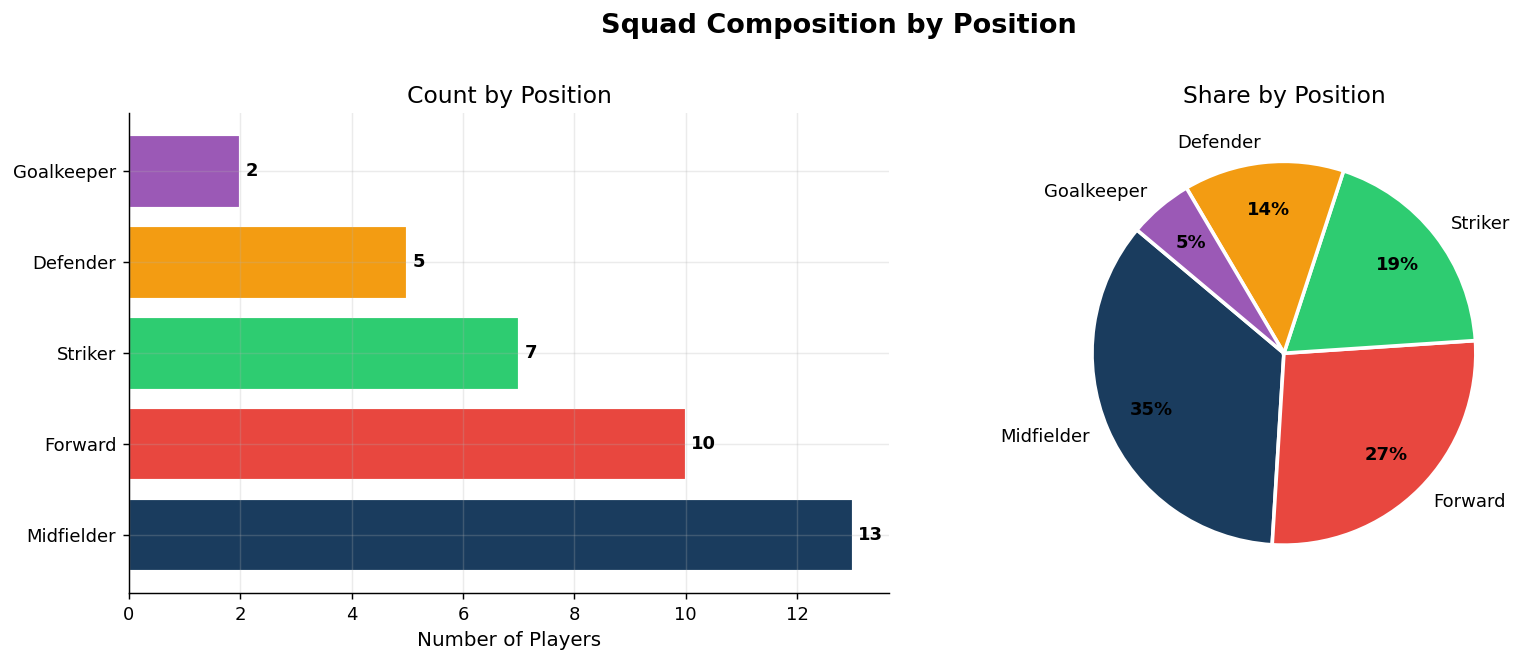

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Squad Composition by Position', fontsize=15, fontweight='bold', y=1.01)

pos_counts = df['position'].value_counts()
colors = PALETTE[:len(pos_counts)]

# Bar chart
ax = axes[0]
bars = ax.barh(pos_counts.index, pos_counts.values, color=colors, edgecolor='white', linewidth=1.2)
ax.set_xlabel('Number of Players')
ax.set_title('Count by Position')
for bar in bars:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            int(bar.get_width()), va='center', fontweight='bold')

# Pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    pos_counts.values,
    labels=pos_counts.index,
    autopct='%1.0f%%',
    colors=colors,
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'}
)
for at in autotexts:
    at.set_fontweight('bold')
ax2.set_title('Share by Position')

plt.tight_layout()
plt.show()

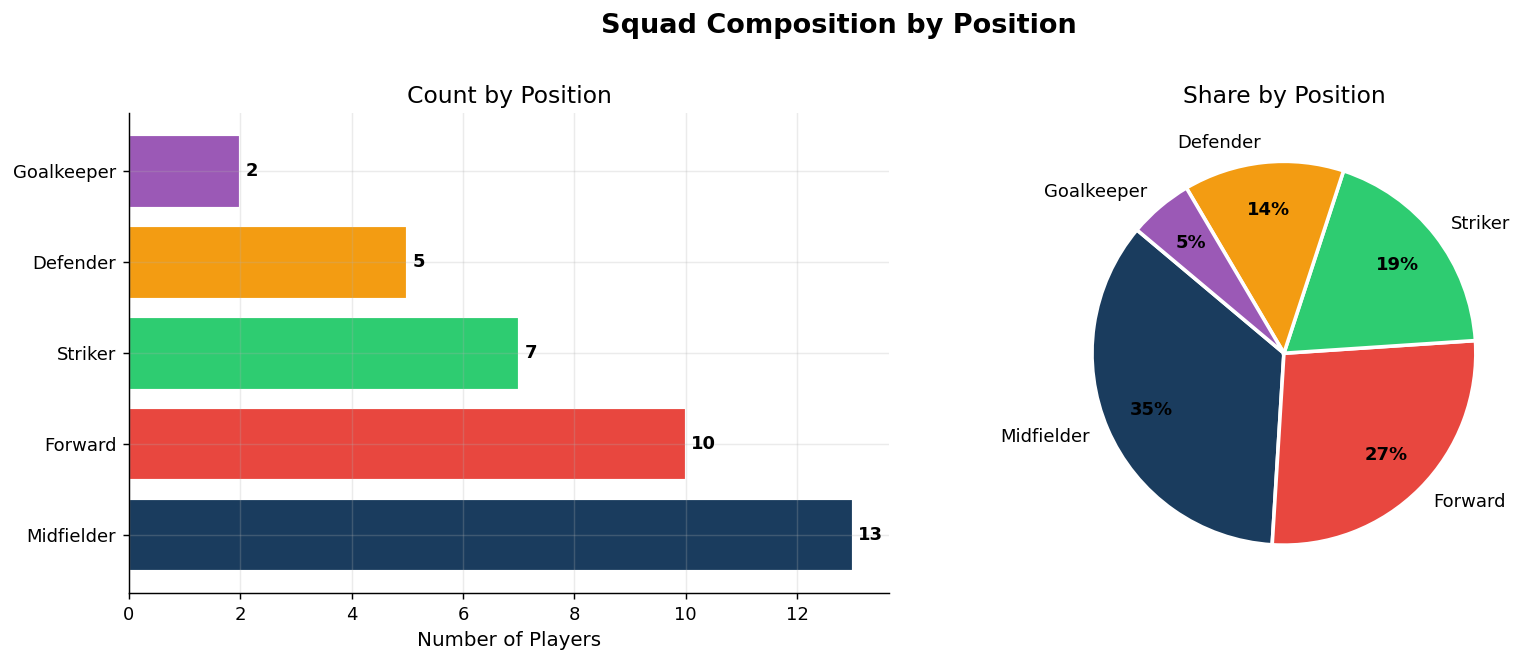

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Squad Composition by Position', fontsize=15, fontweight='bold', y=1.01)

pos_counts = df['position'].value_counts()
colors = PALETTE[:len(pos_counts)]

# Bar chart
ax = axes[0]
bars = ax.barh(pos_counts.index, pos_counts.values, color=colors, edgecolor='white', linewidth=1.2)
ax.set_xlabel('Number of Players')
ax.set_title('Count by Position')
for bar in bars:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            int(bar.get_width()), va='center', fontweight='bold')

# Pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    pos_counts.values,
    labels=pos_counts.index,
    autopct='%1.0f%%',
    colors=colors,
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'}
)
for at in autotexts:
    at.set_fontweight('bold')
ax2.set_title('Share by Position')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'squad_composition.png'))
plt.show()

### 5.3 Top 10 Performers — Goals, Assists & Goal Contributions

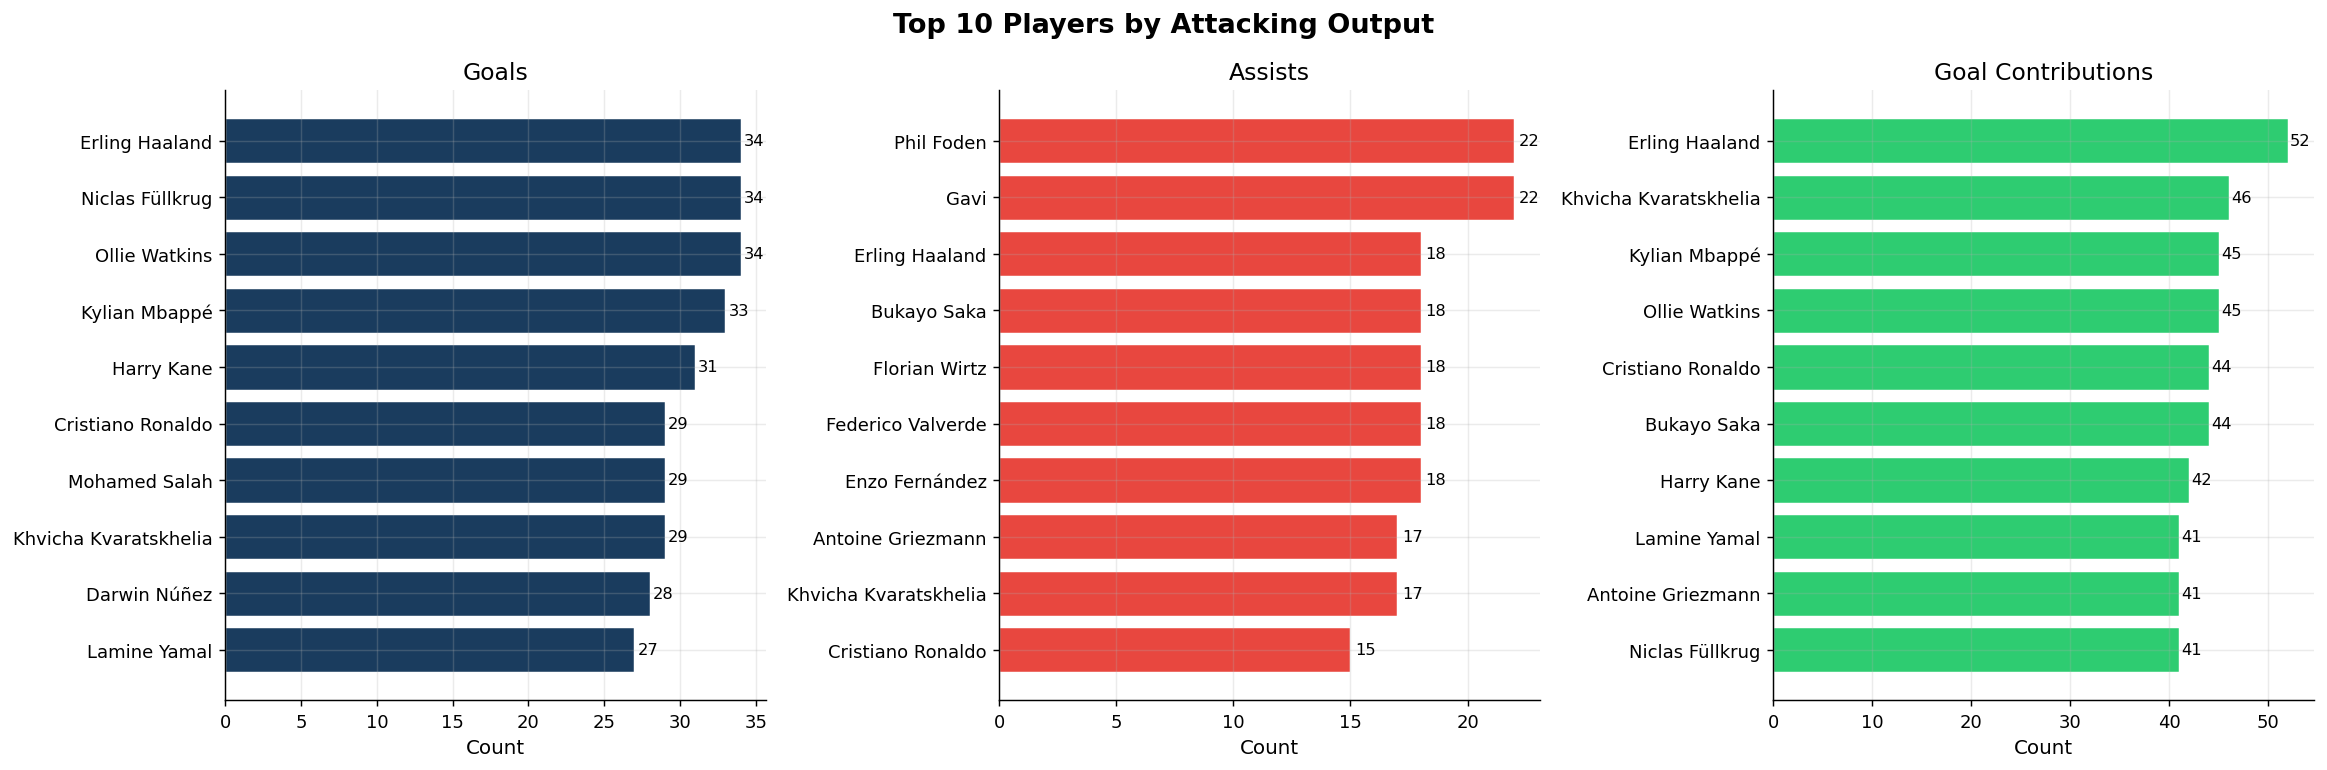

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Top 10 Players by Attacking Output', fontsize=15, fontweight='bold')

metrics = [
    ('goals',             'Goals',              PALETTE[0]),
    ('assists',           'Assists',             PALETTE[1]),
    ('goal_contribution', 'Goal Contributions',  PALETTE[2]),
]

for ax, (col, label, color) in zip(axes, metrics):
    top10 = df.nlargest(10, col)[['player_name', col]]
    bars = ax.barh(top10['player_name'][::-1], top10[col][::-1],
                   color=color, edgecolor='white', linewidth=0.8)
    ax.set_title(label)
    ax.set_xlabel('Count')
    for bar in bars:
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                int(bar.get_width()), va='center', fontsize=9)

plt.tight_layout()
plt.show()

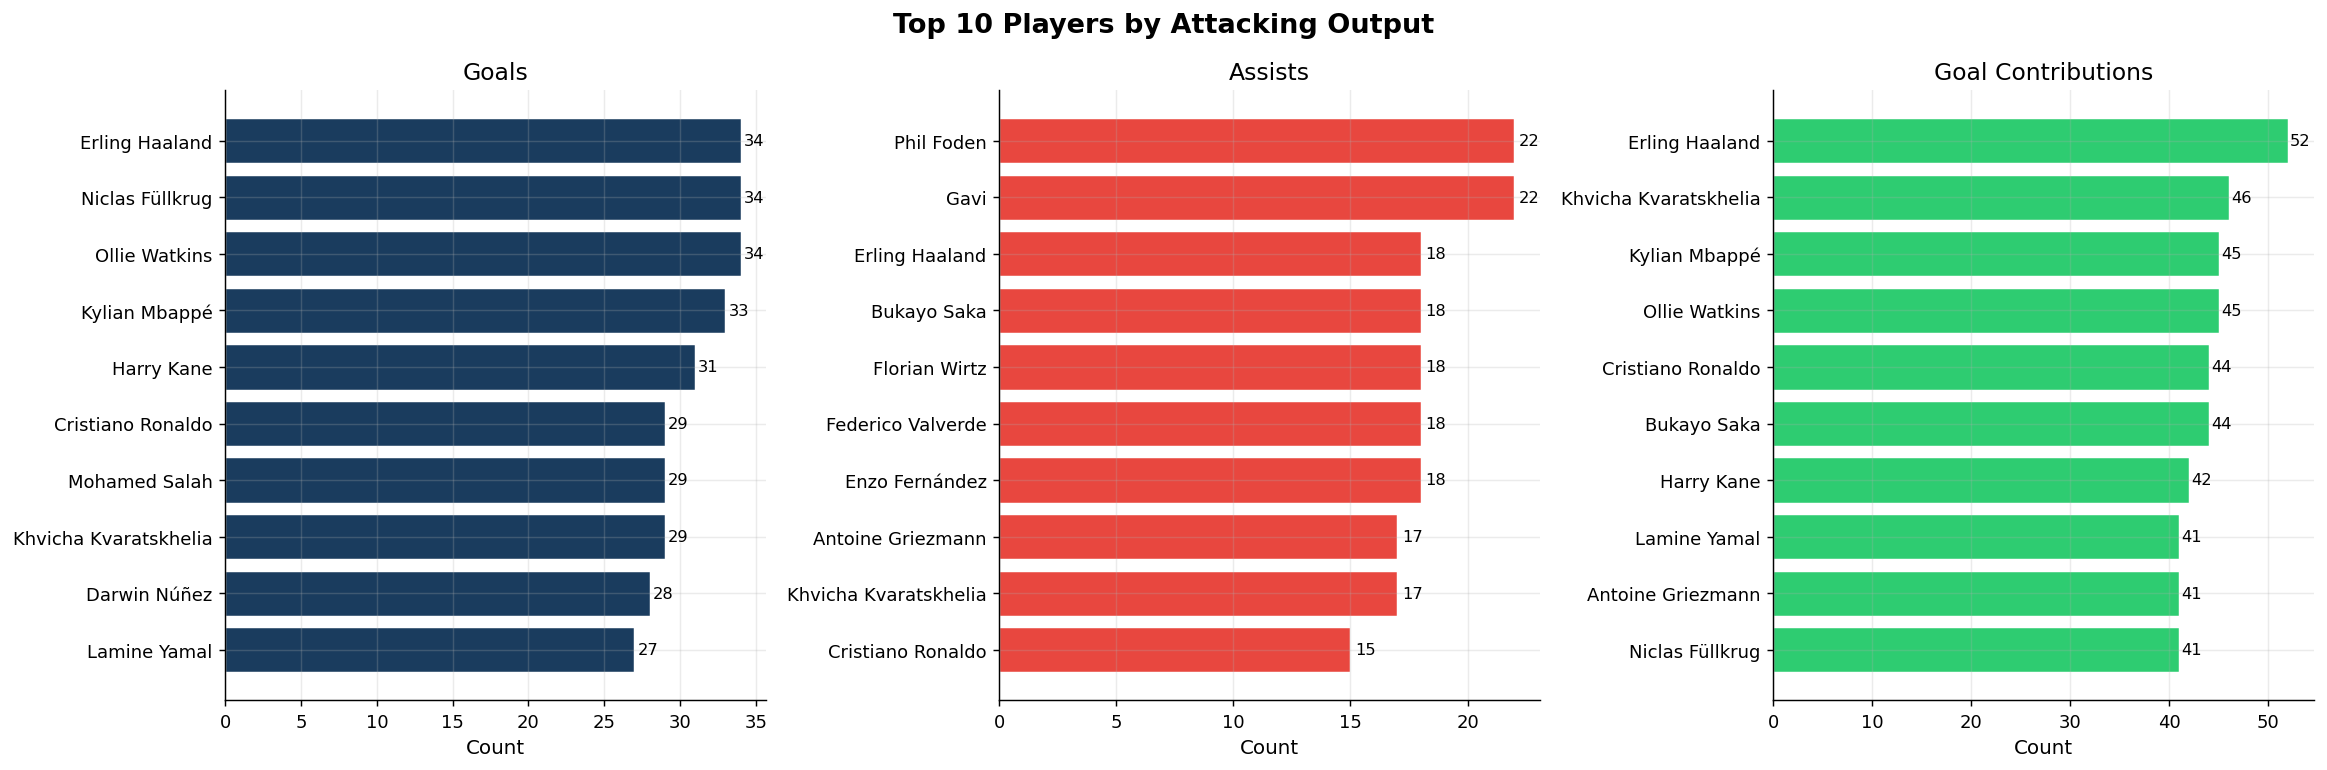

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Top 10 Players by Attacking Output', fontsize=15, fontweight='bold')

metrics = [
    ('goals',             'Goals',              PALETTE[0]),
    ('assists',           'Assists',             PALETTE[1]),
    ('goal_contribution', 'Goal Contributions',  PALETTE[2]),
]

for ax, (col, label, color) in zip(axes, metrics):
    top10 = df.nlargest(10, col)[['player_name', col]]
    bars = ax.barh(top10['player_name'][::-1], top10[col][::-1],
                   color=color, edgecolor='white', linewidth=0.8)
    ax.set_title(label)
    ax.set_xlabel('Count')
    for bar in bars:
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                int(bar.get_width()), va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'top_10_attacking_output.png'))
plt.show()

### 5.4 Distribution of Key Metrics

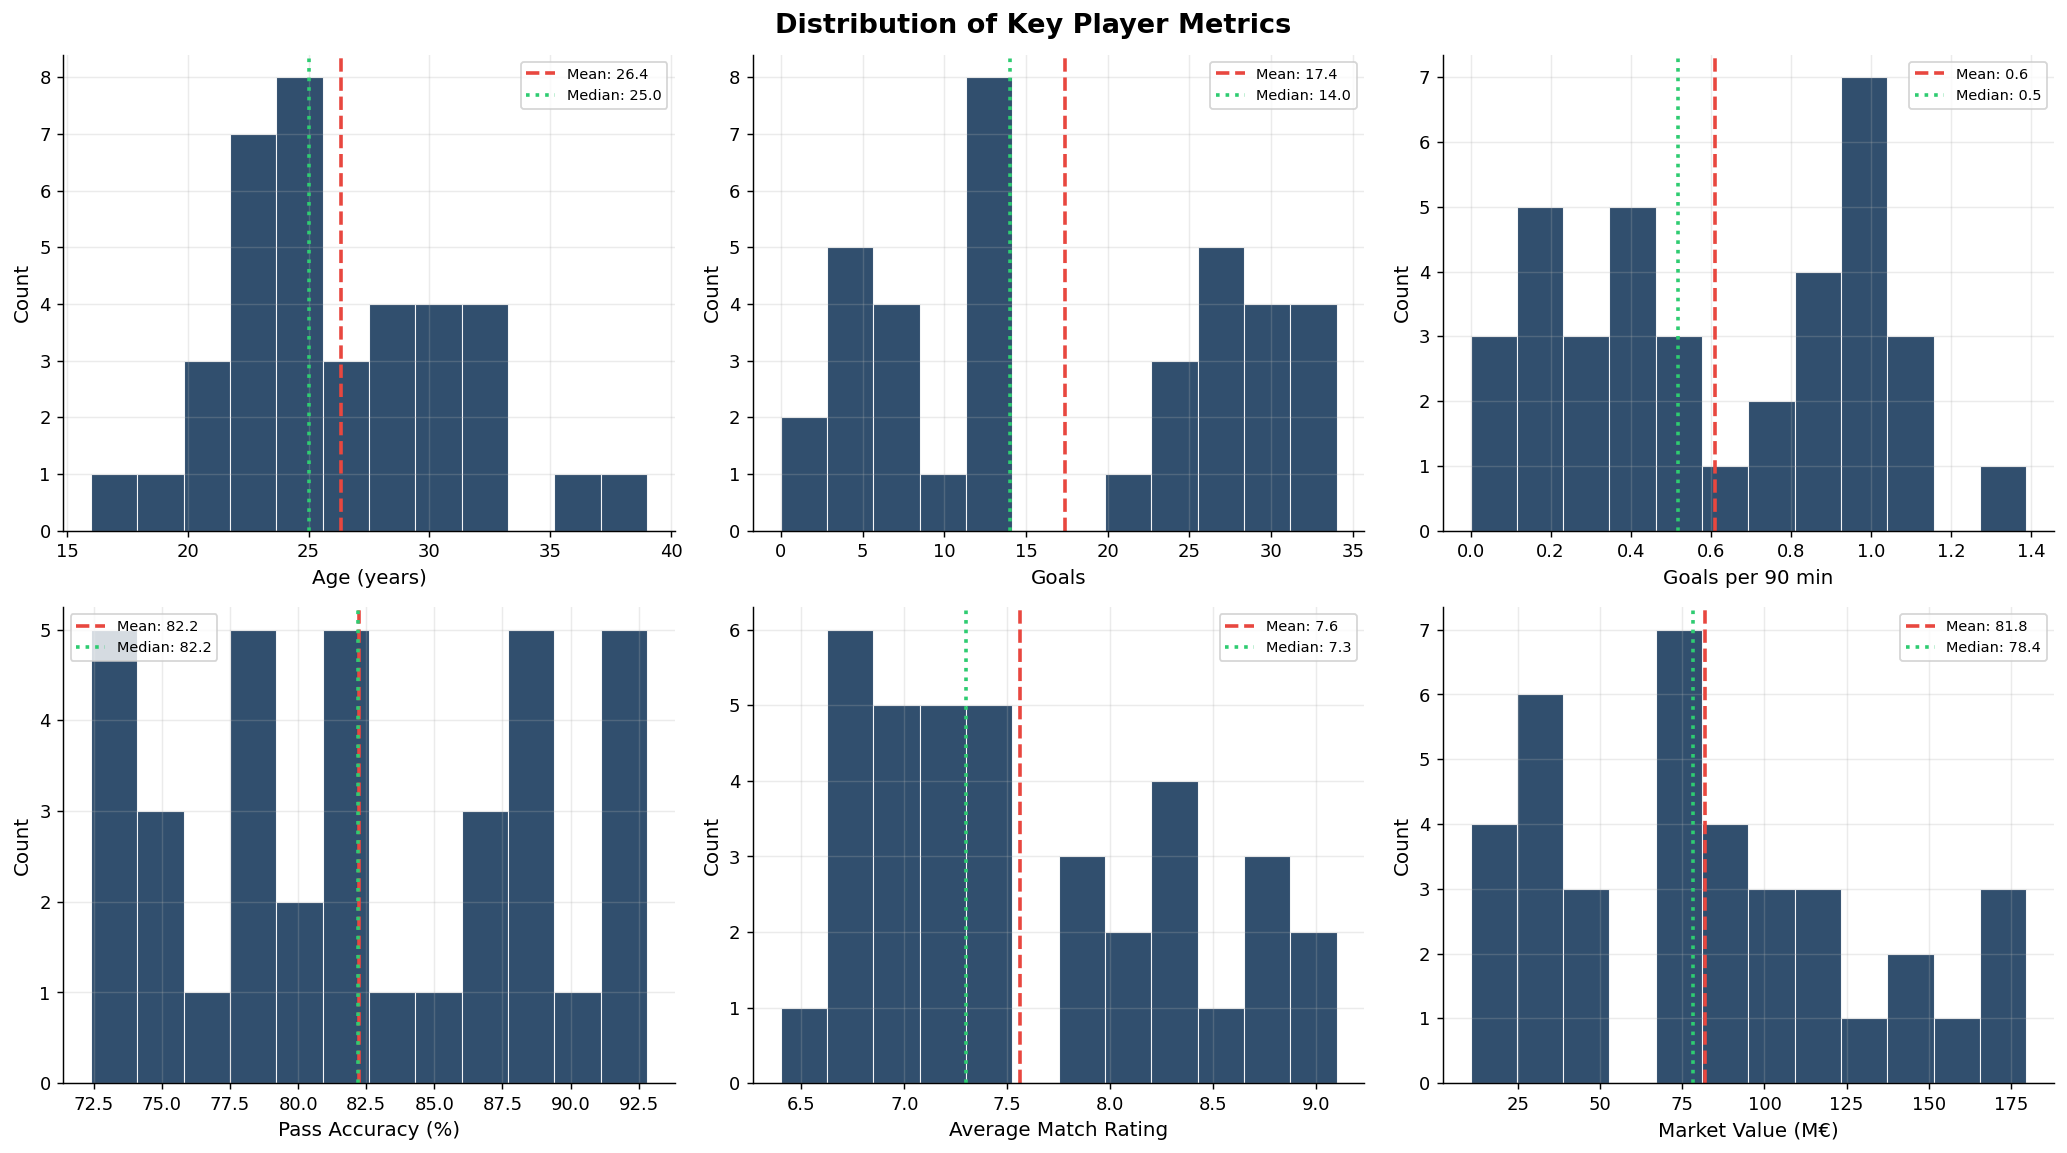

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribution of Key Player Metrics', fontsize=15, fontweight='bold')

dist_cols = [
    ('age',                 'Age (years)'),
    ('goals',               'Goals'),
    ('goals_p90',           'Goals per 90 min'),
    ('pass_accuracy_pct',   'Pass Accuracy (%)'),
    ('avg_rating',          'Average Match Rating'),
    ('market_value_m_eur',  'Market Value (M€)'),
]

for ax, (col, xlabel) in zip(axes.flat, dist_cols):
    data = df[col].dropna()
    ax.hist(data, bins=12, color=PALETTE[0], edgecolor='white', linewidth=0.6, alpha=0.9)
    ax.axvline(data.mean(), color=PALETTE[1], linewidth=2, linestyle='--', label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color=PALETTE[2], linewidth=2, linestyle=':', label=f'Median: {data.median():.1f}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

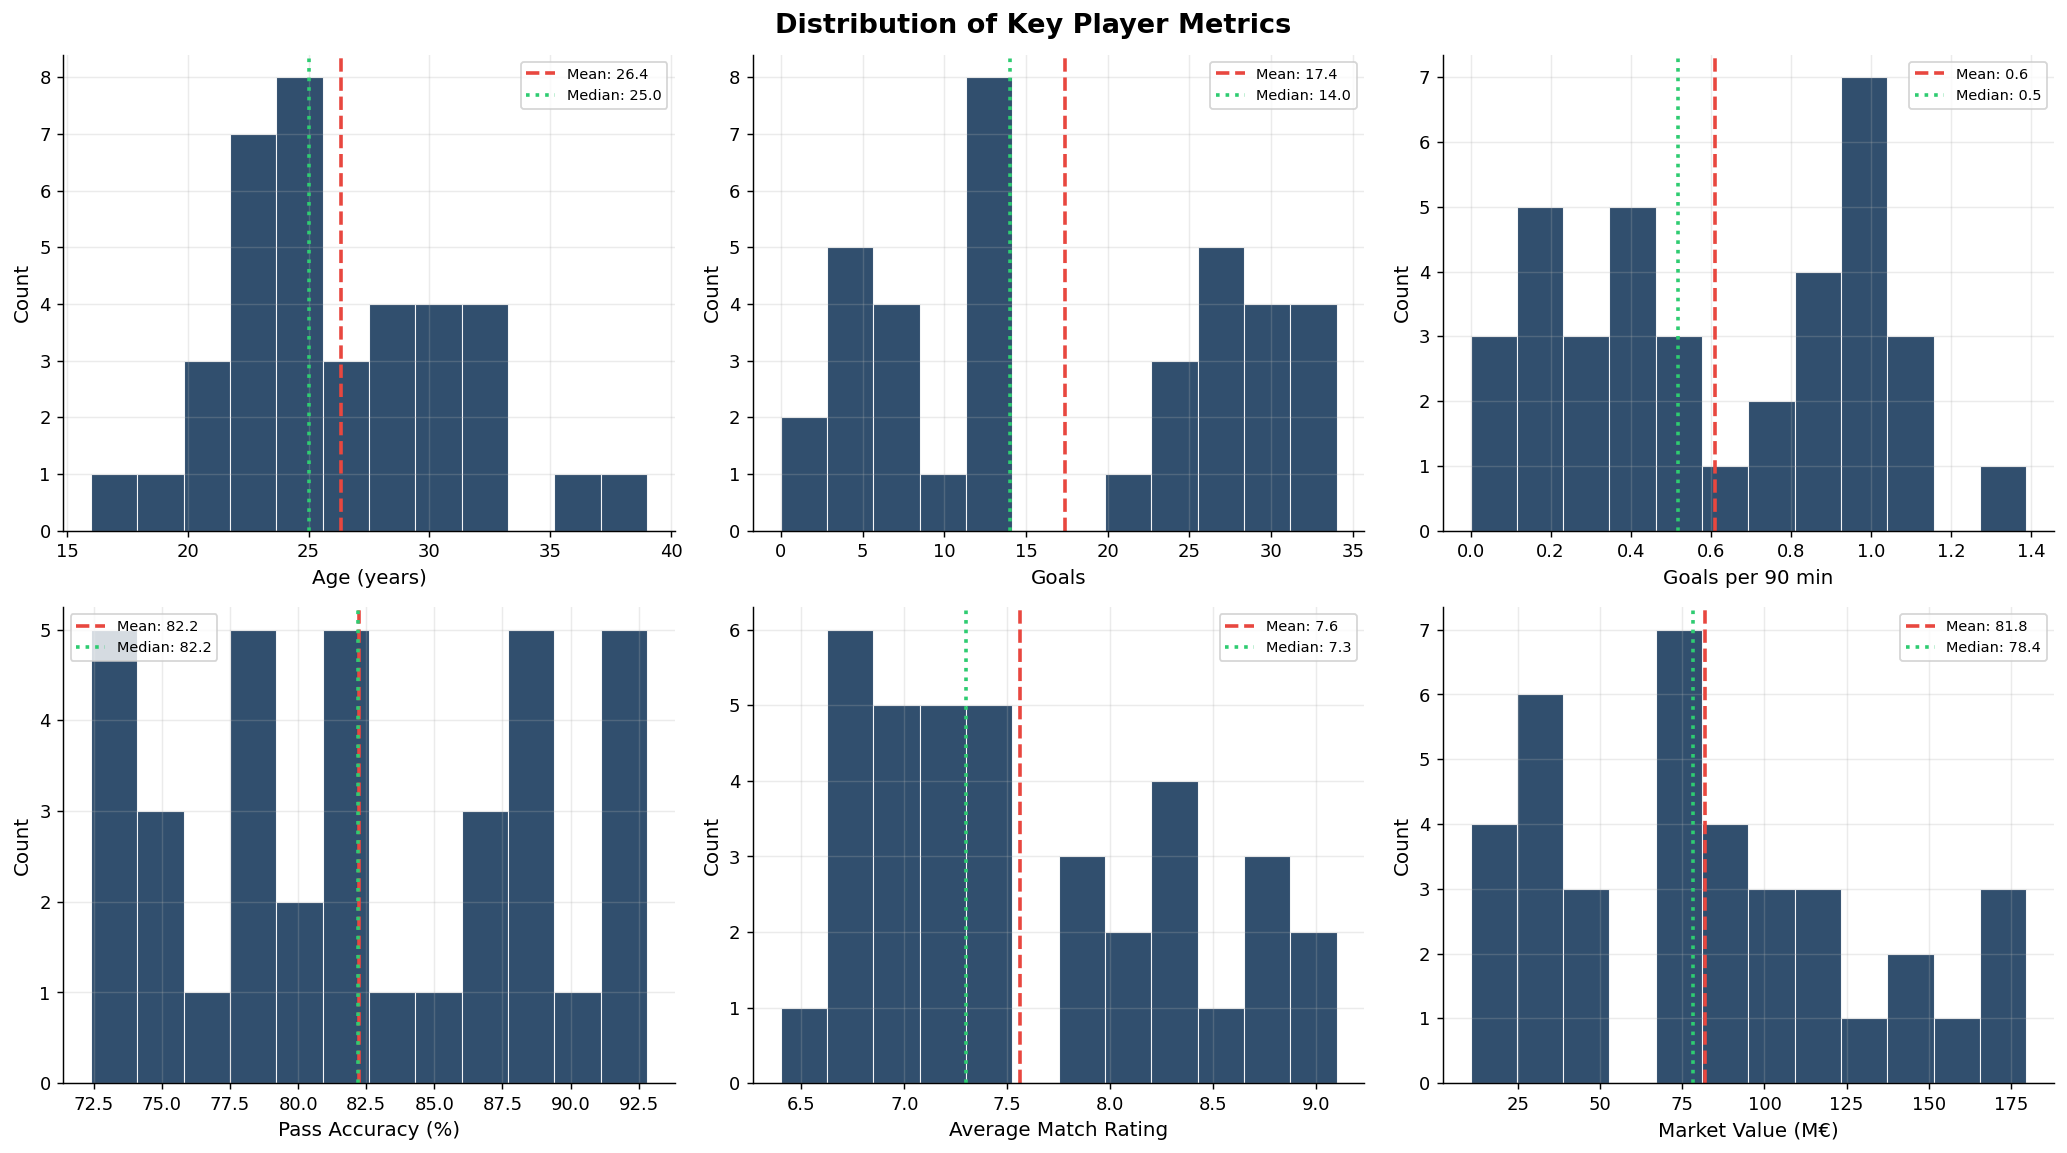

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribution of Key Player Metrics', fontsize=15, fontweight='bold')

dist_cols = [
    ('age',                 'Age (years)'),
    ('goals',               'Goals'),
    ('goals_p90',           'Goals per 90 min'),
    ('pass_accuracy_pct',   'Pass Accuracy (%)'),
    ('avg_rating',          'Average Match Rating'),
    ('market_value_m_eur',  'Market Value (M€)'),
]

for ax, (col, xlabel) in zip(axes.flat, dist_cols):
    data = df[col].dropna()
    ax.hist(data, bins=12, color=PALETTE[0], edgecolor='white', linewidth=0.6, alpha=0.9)
    ax.axvline(data.mean(), color=PALETTE[1], linewidth=2, linestyle='--', label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color=PALETTE[2], linewidth=2, linestyle=':', label=f'Median: {data.median():.1f}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'distribution_key_metrics.png'))
plt.show()

### 5.5 Stats by Position — Box Plots

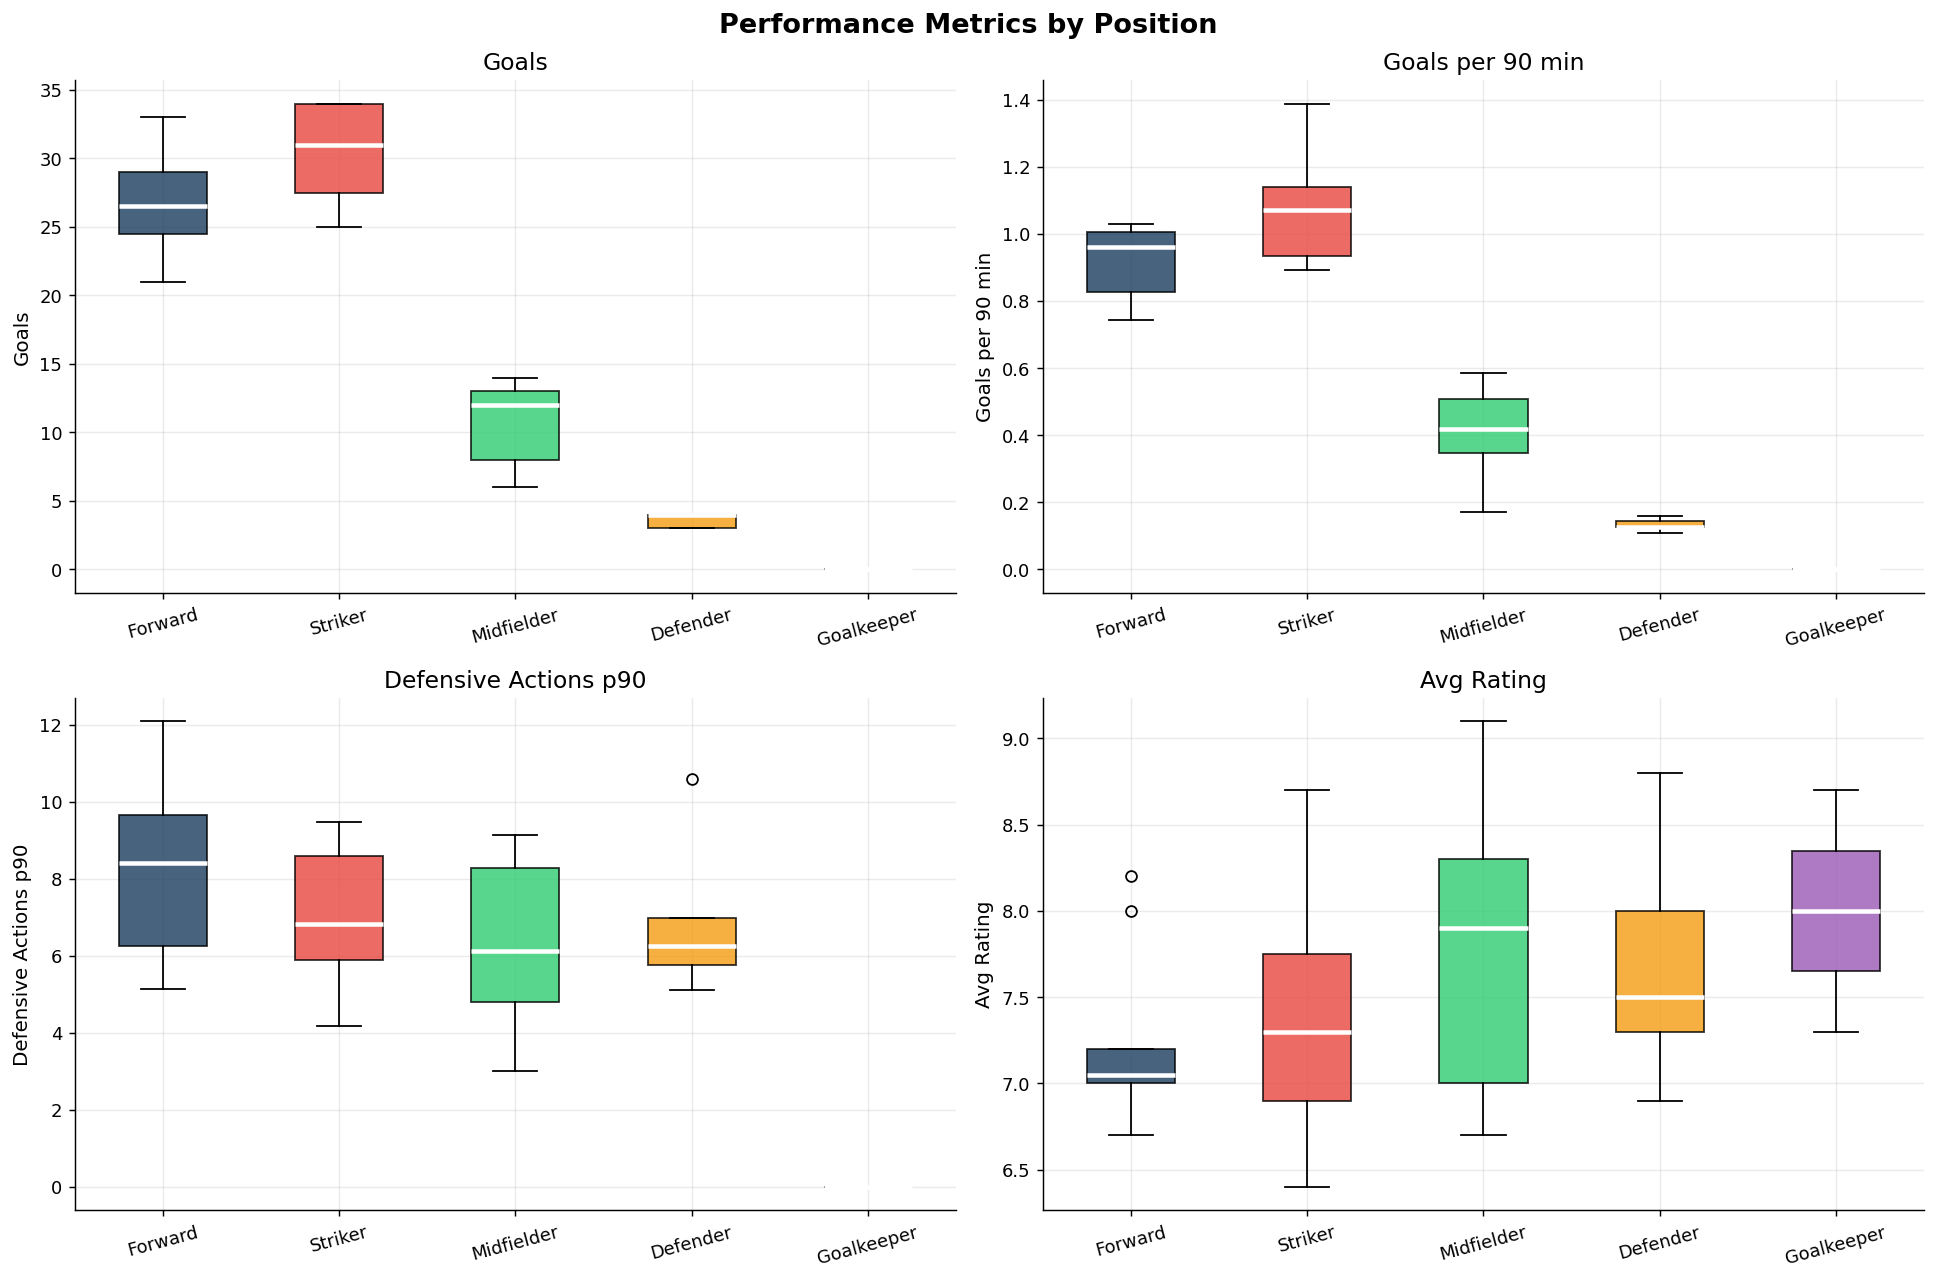

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Performance Metrics by Position', fontsize=15, fontweight='bold')

box_metrics = [
    ('goals',               'Goals'),
    ('goals_p90',           'Goals per 90 min'),
    ('defensive_actions_p90','Defensive Actions p90'),
    ('avg_rating',          'Avg Rating'),
]

pos_order = ['Forward', 'Striker', 'Midfielder', 'Defender', 'Goalkeeper']

for ax, (col, ylabel) in zip(axes.flat, box_metrics):
    existing_pos = [p for p in pos_order if p in df['position'].unique()]
    data_by_pos = [df[df['position'] == p][col].dropna() for p in existing_pos]
    bp = ax.boxplot(data_by_pos, labels=existing_pos, patch_artist=True, notch=False,
                    medianprops={'color':'white','linewidth':2.5})
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_title(ylabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

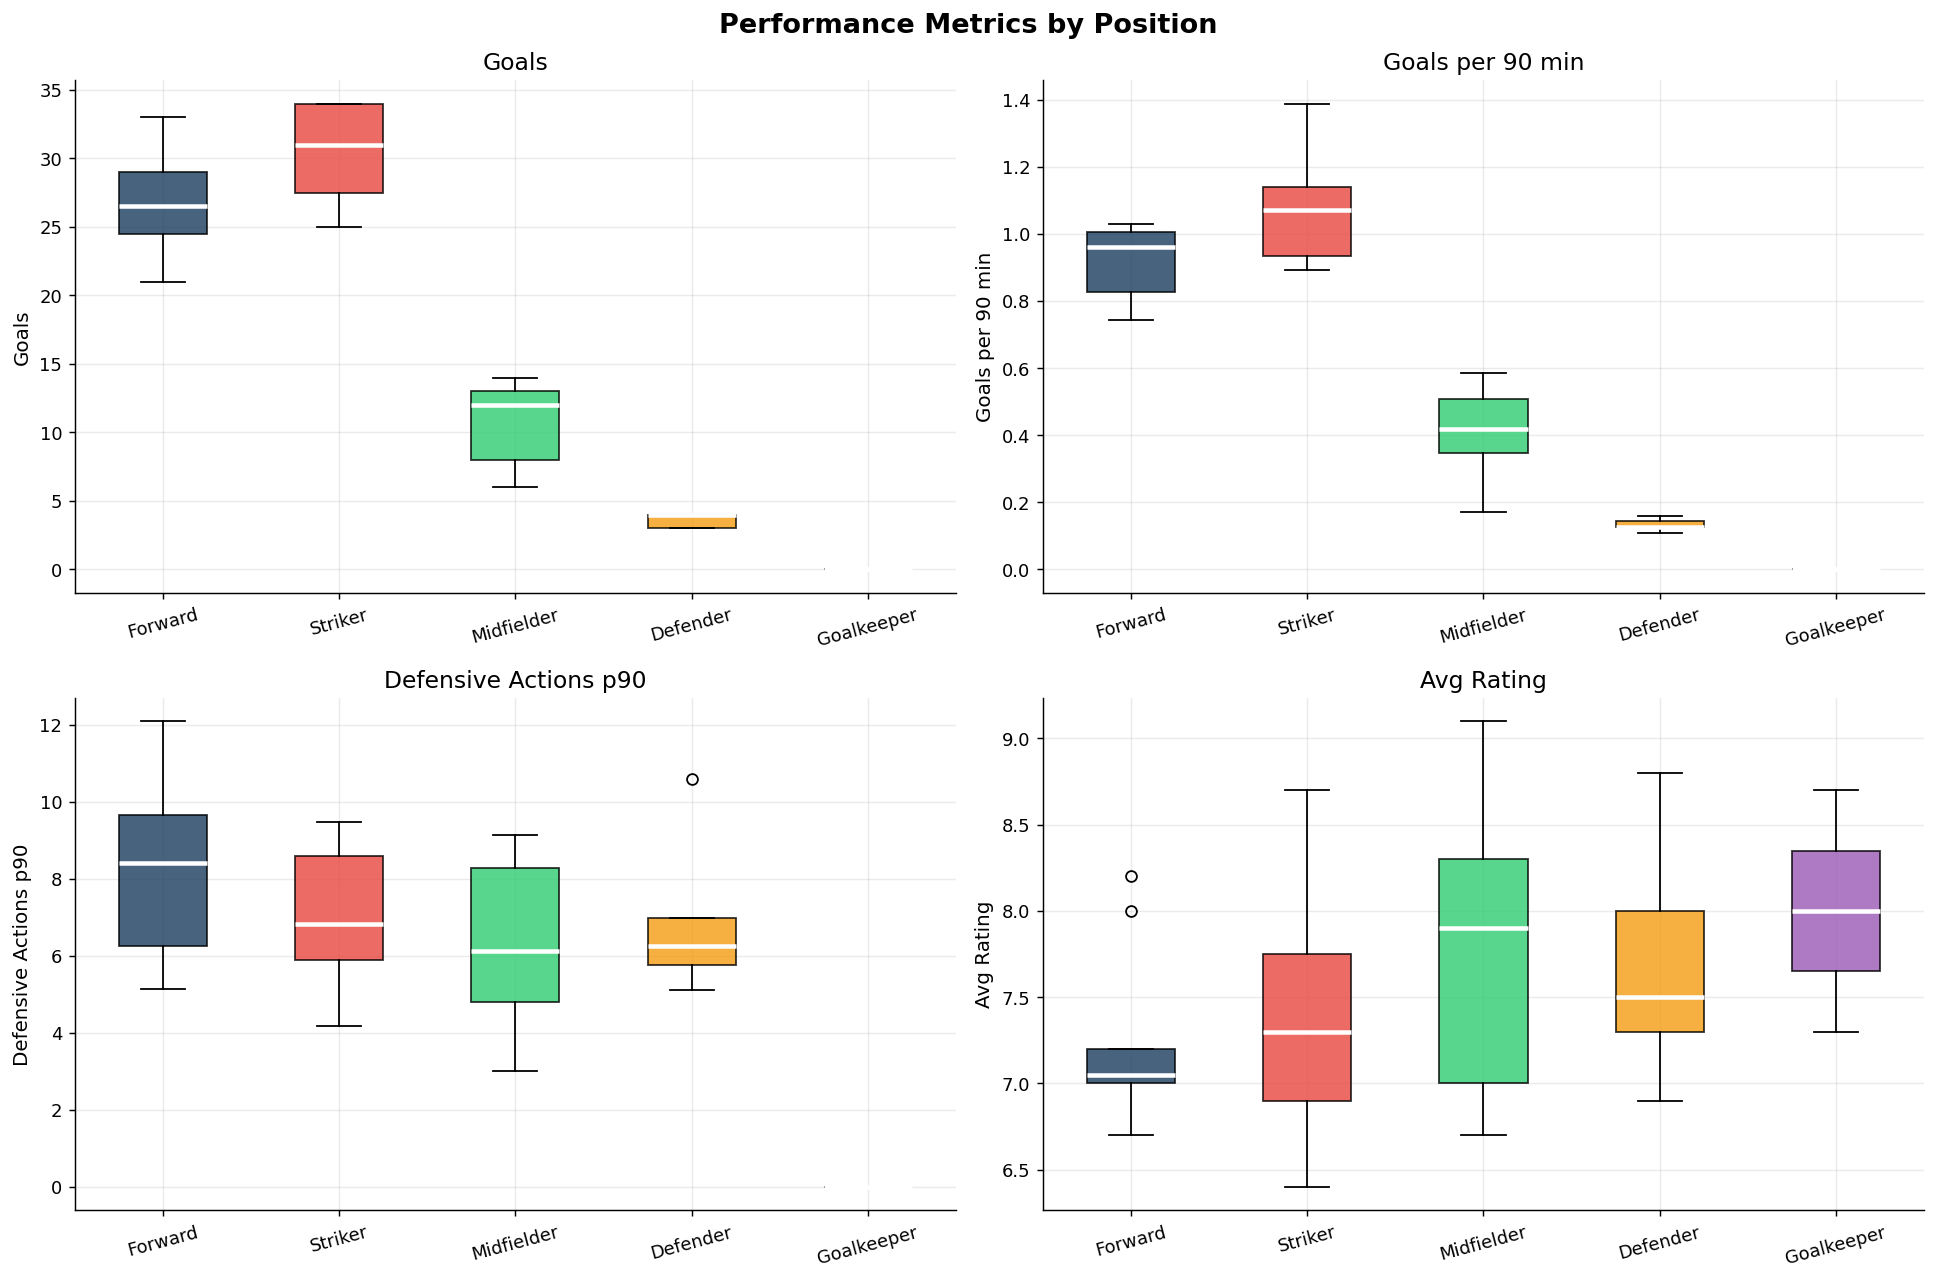

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Performance Metrics by Position', fontsize=15, fontweight='bold')

box_metrics = [
    ('goals',               'Goals'),
    ('goals_p90',           'Goals per 90 min'),
    ('defensive_actions_p90','Defensive Actions p90'),
    ('avg_rating',          'Avg Rating'),
]

pos_order = ['Forward', 'Striker', 'Midfielder', 'Defender', 'Goalkeeper']

for ax, (col, ylabel) in zip(axes.flat, box_metrics):
    existing_pos = [p for p in pos_order if p in df['position'].unique()]
    data_by_pos = [df[df['position'] == p][col].dropna() for p in existing_pos]
    bp = ax.boxplot(data_by_pos, labels=existing_pos, patch_artist=True, notch=False,
                    medianprops={'color':'white','linewidth':2.5})
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_title(ylabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'performance_metrics_by_position.png'))
plt.show()

---
## 6 · Advanced Visualisations

### 6.1 Correlation Heatmap

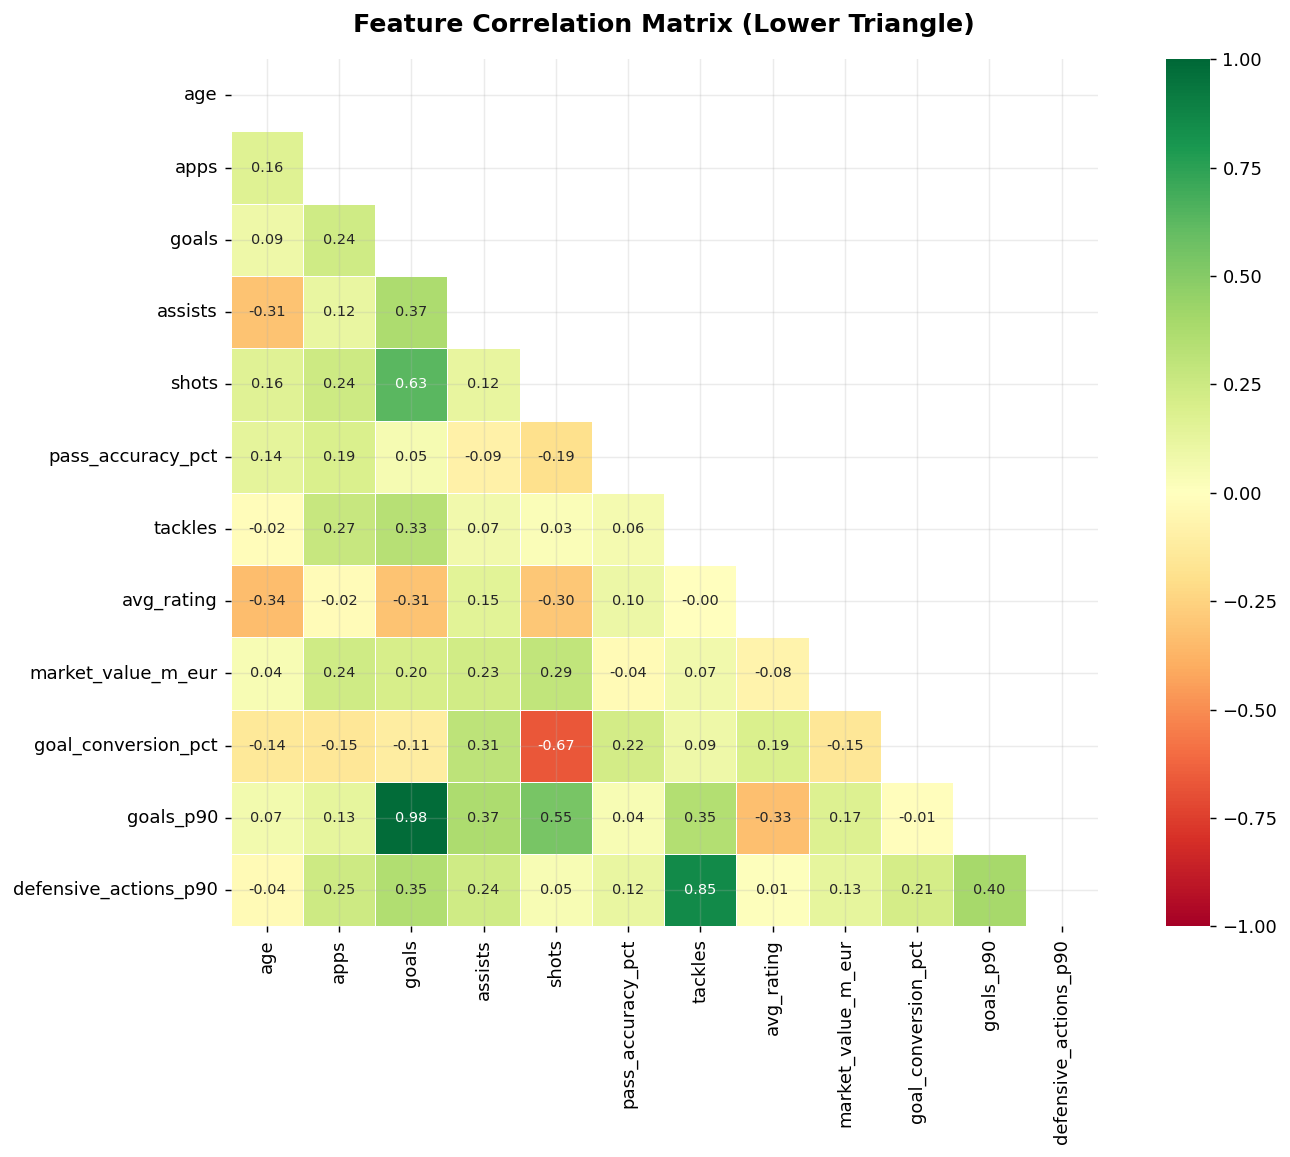

In [32]:
corr_cols = ['age','apps','goals','assists','shots','pass_accuracy_pct',
             'tackles','avg_rating','market_value_m_eur',
             'goal_conversion_pct','goals_p90','defensive_actions_p90']
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax
)
ax.set_title('Feature Correlation Matrix (Lower Triangle)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

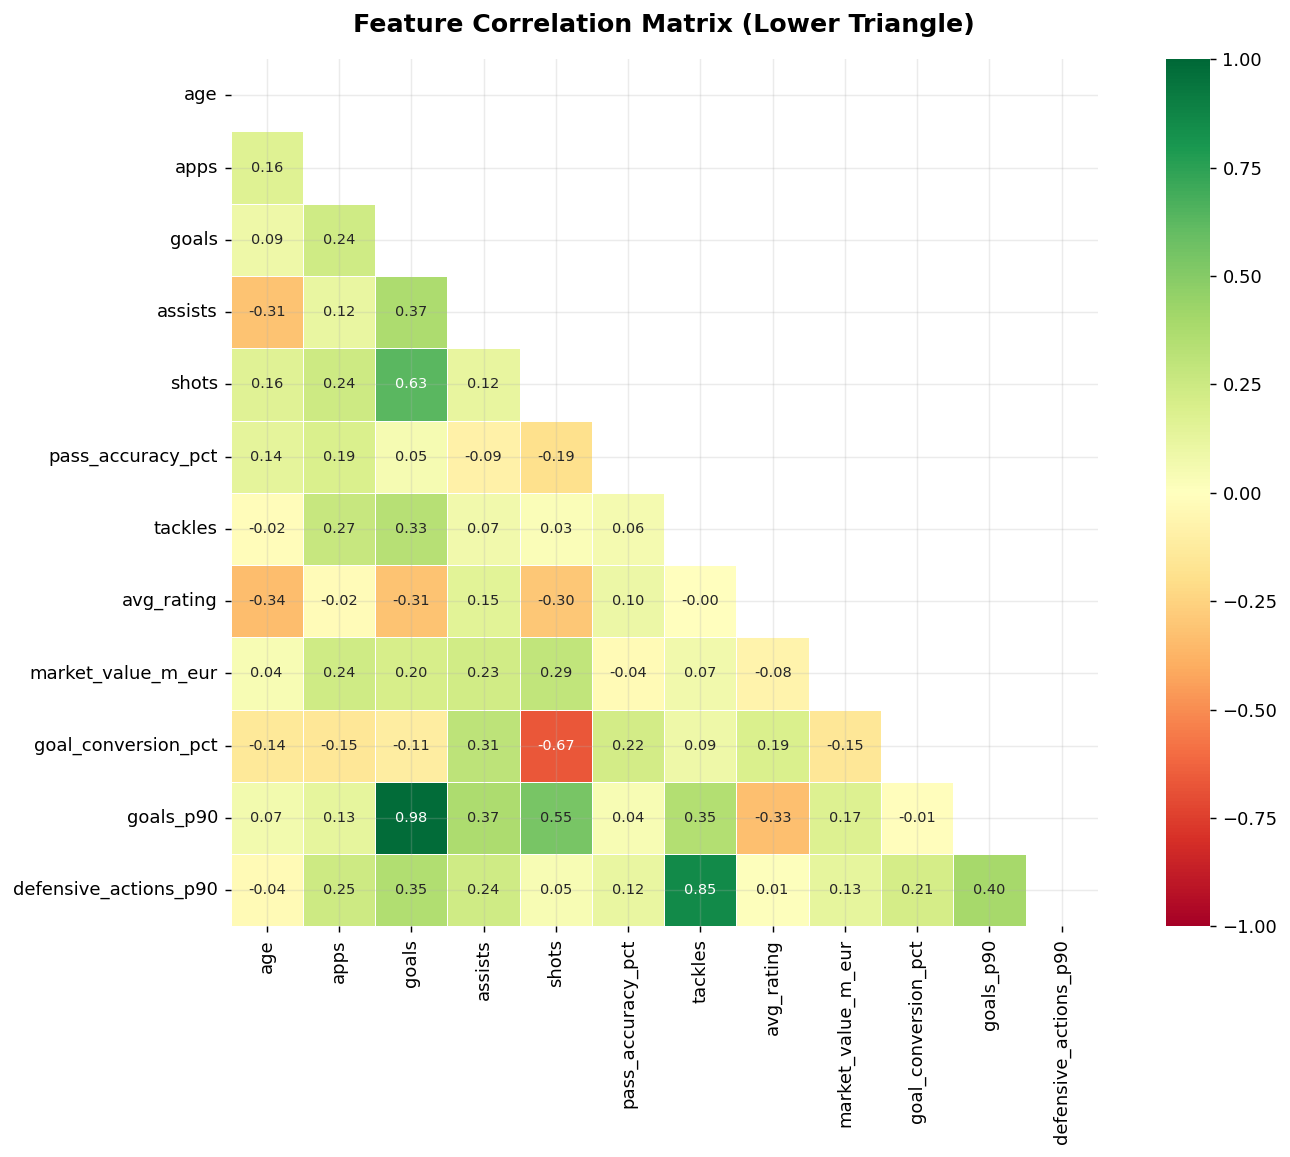

In [44]:
corr_cols = ['age','apps','goals','assists','shots','pass_accuracy_pct',
             'tackles','avg_rating','market_value_m_eur',
             'goal_conversion_pct','goals_p90','defensive_actions_p90']
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax
)
ax.set_title('Feature Correlation Matrix (Lower Triangle)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'feature_correlation_matrix.png'))
plt.show()

### 6.2 Scatter — Market Value vs Goal Contributions

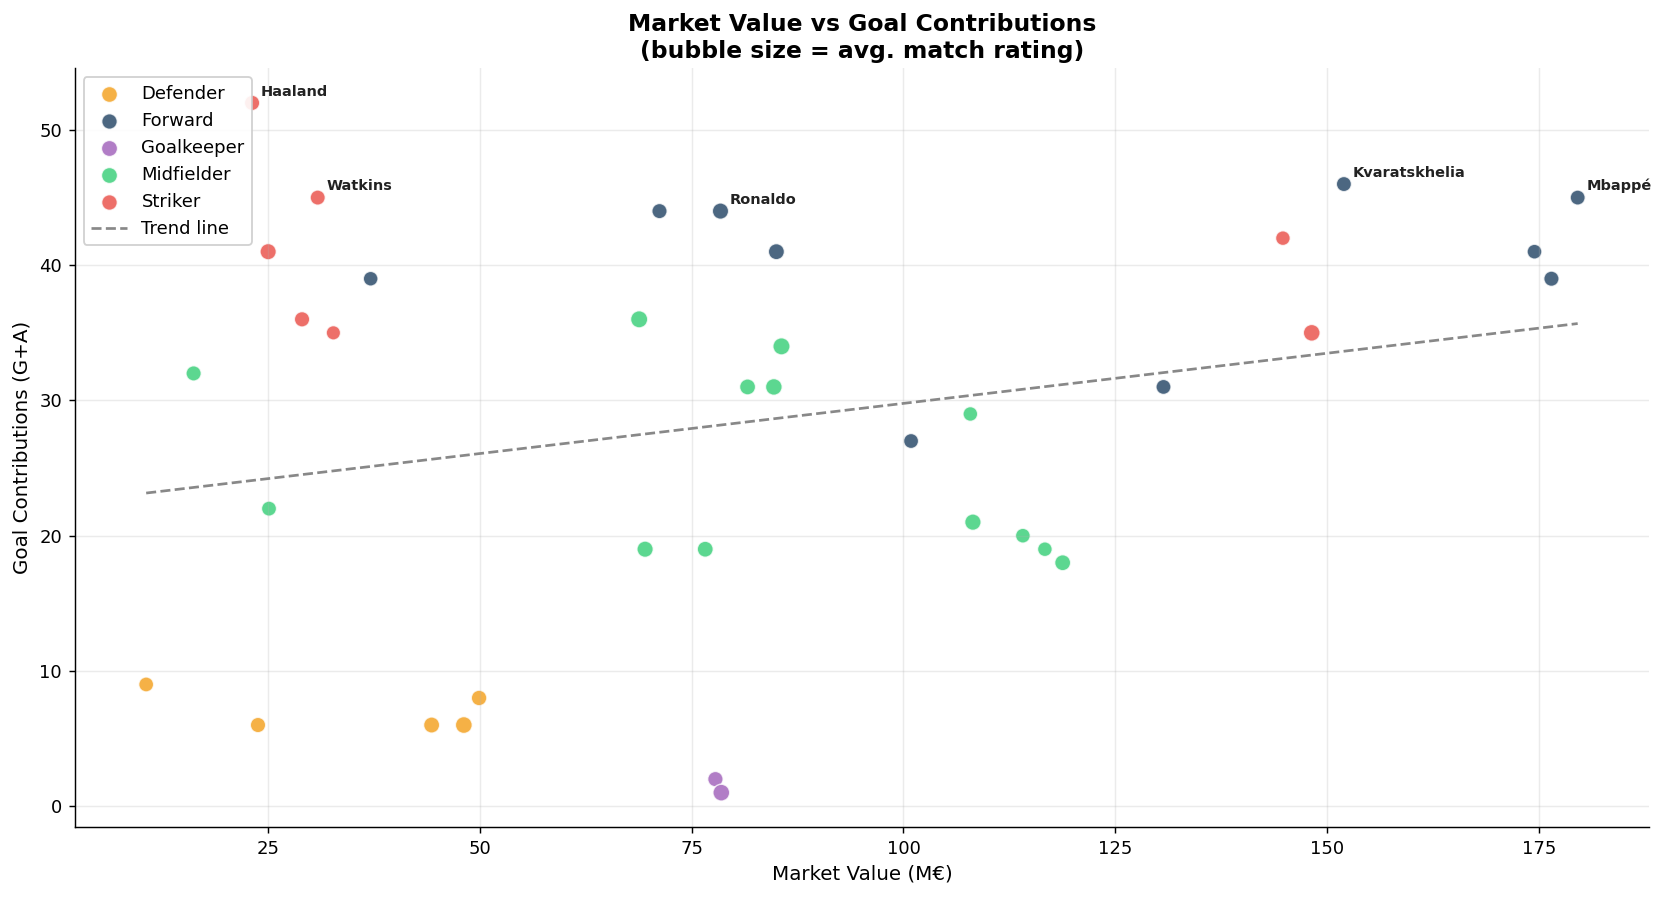

In [33]:
fig, ax = plt.subplots(figsize=(13, 7))

pos_colors = {'Forward': PALETTE[0], 'Striker': PALETTE[1],
              'Midfielder': PALETTE[2], 'Defender': PALETTE[3],
              'Goalkeeper': PALETTE[4]}

for pos, grp in df.groupby('position'):
    ax.scatter(
        grp['market_value_m_eur'],
        grp['goal_contribution'],
        label=pos,
        color=pos_colors.get(pos, 'grey'),
        s=grp['avg_rating'] * 10,   # bubble size = rating
        alpha=0.78,
        edgecolors='white',
        linewidth=0.8
    )

# Annotate top contributors
top5 = df.nlargest(5, 'goal_contribution')
for _, row in top5.iterrows():
    ax.annotate(
        row['player_name'].split()[-1],
        (row['market_value_m_eur'], row['goal_contribution']),
        xytext=(5, 4), textcoords='offset points',
        fontsize=8, fontweight='bold',
        color='#222'
    )

# Trend line
x = df['market_value_m_eur'].dropna()
y = df['goal_contribution'][x.index].dropna()
m, b = np.polyfit(x[y.index], y, 1)
xline = np.linspace(x.min(), x.max(), 100)
ax.plot(xline, m * xline + b, '--', color='#888', linewidth=1.5, label='Trend line')

ax.set_xlabel('Market Value (M€)')
ax.set_ylabel('Goal Contributions (G+A)')
ax.set_title('Market Value vs Goal Contributions\n(bubble size = avg. match rating)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.show()

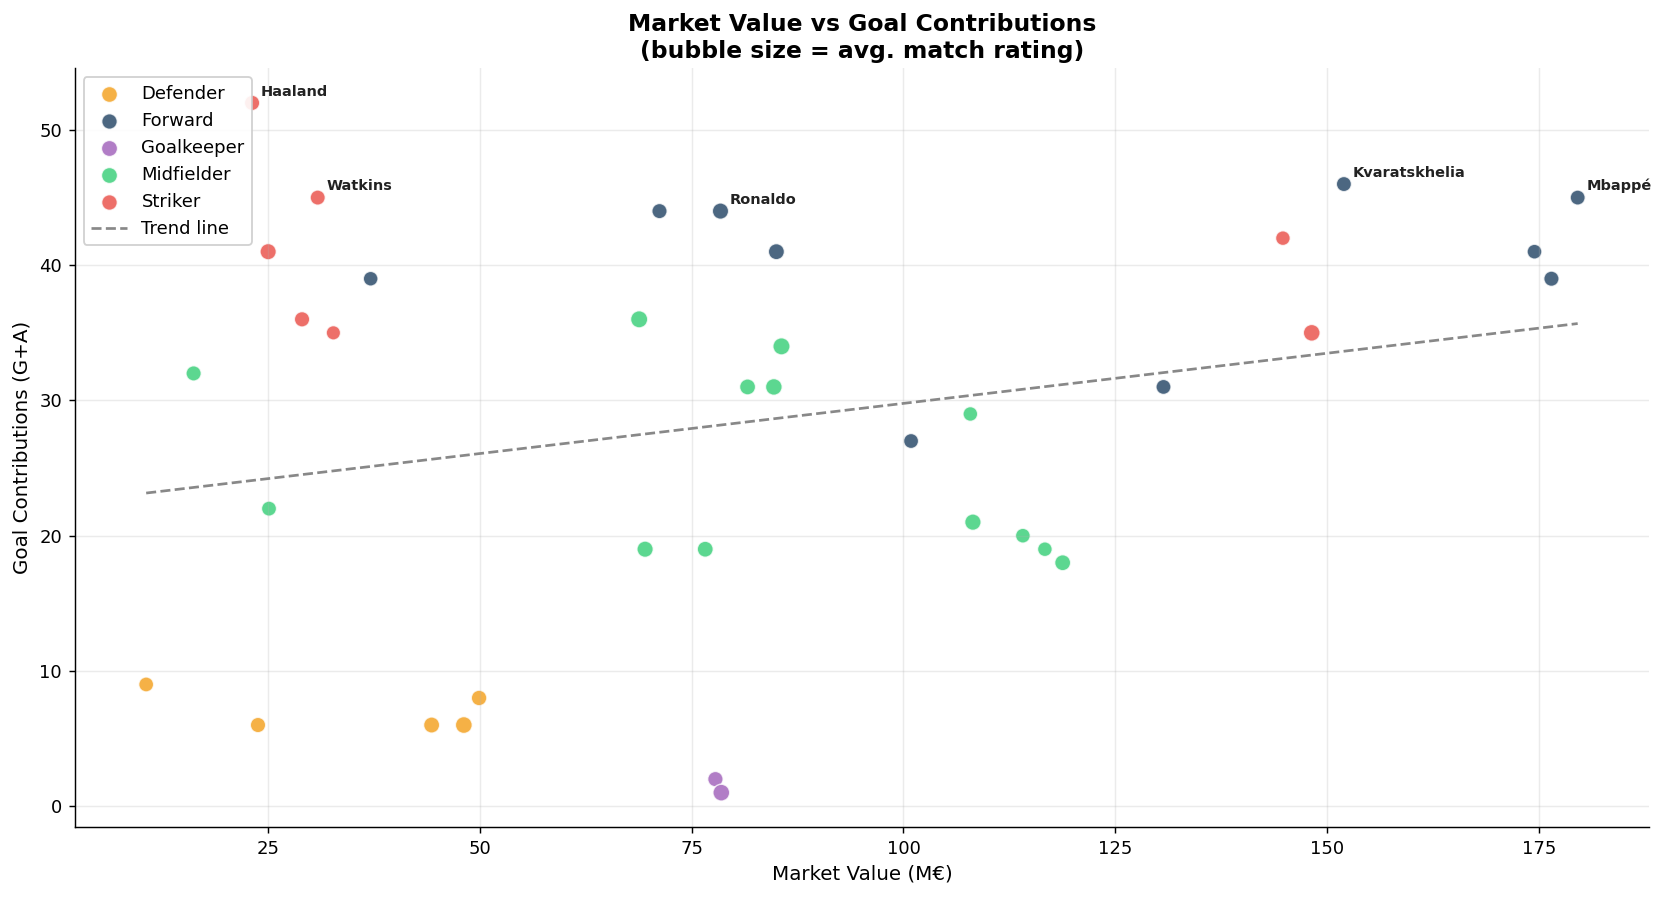

In [45]:
fig, ax = plt.subplots(figsize=(13, 7))

pos_colors = {'Forward': PALETTE[0], 'Striker': PALETTE[1],
              'Midfielder': PALETTE[2], 'Defender': PALETTE[3],
              'Goalkeeper': PALETTE[4]}

for pos, grp in df.groupby('position'):
    ax.scatter(
        grp['market_value_m_eur'],
        grp['goal_contribution'],
        label=pos,
        color=pos_colors.get(pos, 'grey'),
        s=grp['avg_rating'] * 10,   # bubble size = rating
        alpha=0.78,
        edgecolors='white',
        linewidth=0.8
    )

# Annotate top contributors
top5 = df.nlargest(5, 'goal_contribution')
for _, row in top5.iterrows():
    ax.annotate(
        row['player_name'].split()[-1],
        (row['market_value_m_eur'], row['goal_contribution']),
        xytext=(5, 4), textcoords='offset points',
        fontsize=8, fontweight='bold',
        color='#222'
    )

# Trend line
x = df['market_value_m_eur'].dropna()
y = df['goal_contribution'][x.index].dropna()
m, b = np.polyfit(x[y.index], y, 1)
xline = np.linspace(x.min(), x.max(), 100)
ax.plot(xline, m * xline + b, '--', color='#888', linewidth=1.5, label='Trend line')

ax.set_xlabel('Market Value (M€)')
ax.set_ylabel('Goal Contributions (G+A)')
ax.set_title('Market Value vs Goal Contributions\n(bubble size = avg. match rating)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'market_value_vs_goal_contributions.png'))
plt.show()

### 6.3 Radar Chart — Top 5 Attackers Profile

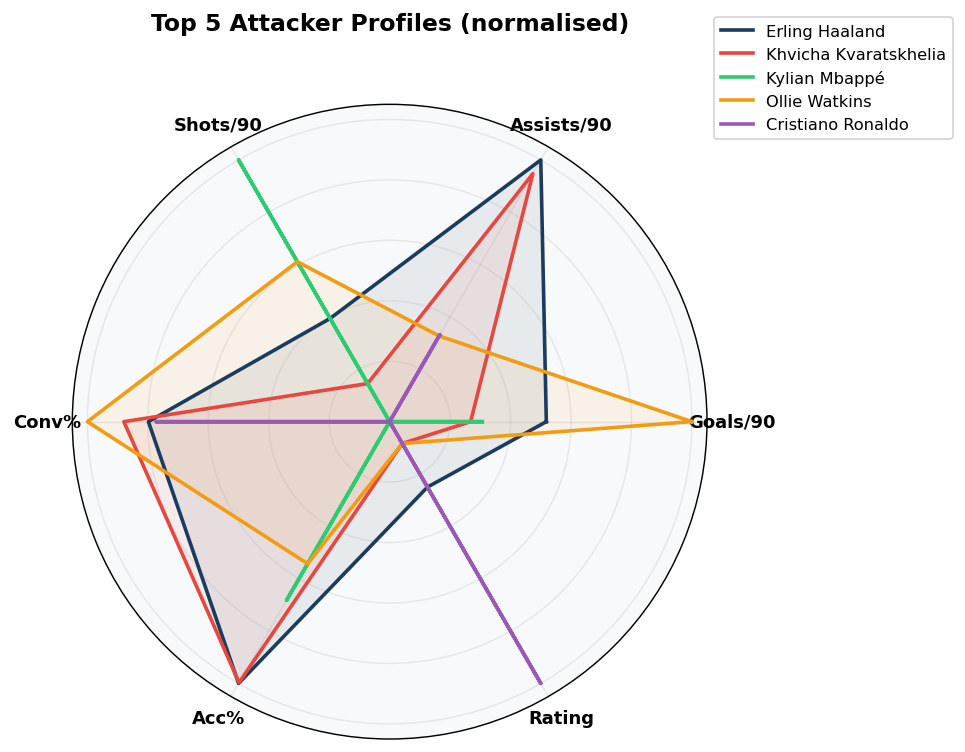

In [34]:
radar_metrics = ['goals_p90','assists_p90','shots_p90',
                 'goal_conversion_pct','shot_accuracy_pct','avg_rating']
radar_metrics = [c for c in radar_metrics if c in df.columns]
radar_labels  = ['Goals/90','Assists/90','Shots/90','Conv%','Acc%','Rating']

attackers = df[df['position'].isin(['Forward','Striker'])].nlargest(5,'goal_contribution')

# Normalise 0-1 within the attacker subset
radar_df = attackers[['player_name'] + radar_metrics].set_index('player_name')
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())

N = len(radar_metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})
ax.set_facecolor('#F8F9FA')

for i, (player, row) in enumerate(radar_norm.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, color=PALETTE[i], linewidth=2, label=player)
    ax.fill(angles, values, color=PALETTE[i], alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, size=10, fontweight='bold')
ax.set_yticklabels([])
ax.set_title('Top 5 Attacker Profiles (normalised)', size=13,
             fontweight='bold', y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=9)

plt.tight_layout()
plt.show()

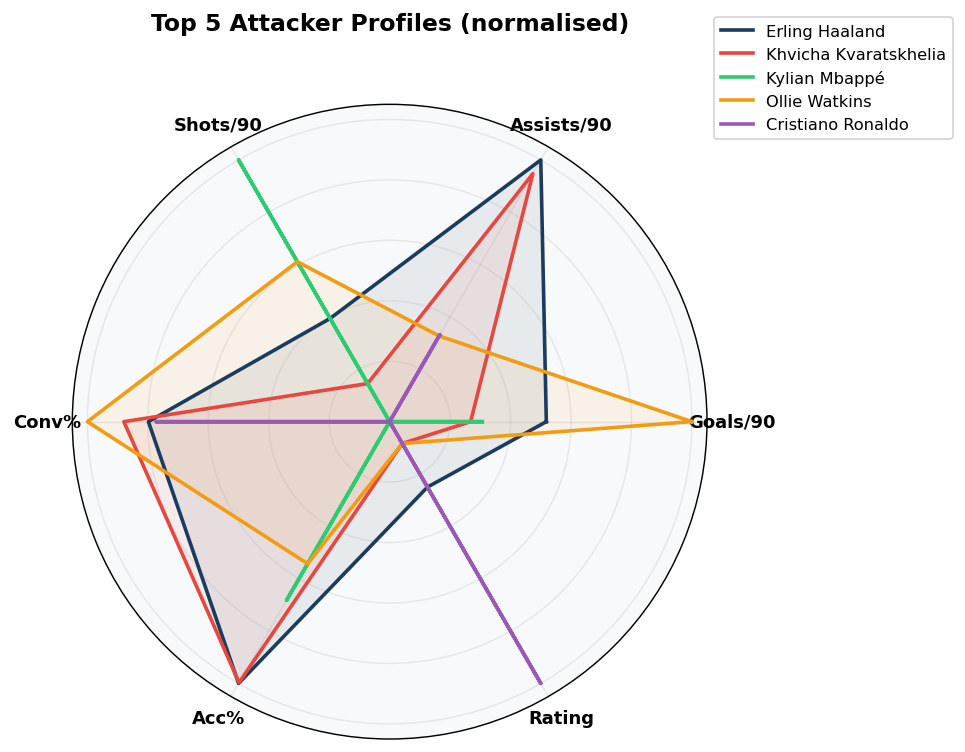

In [46]:
radar_metrics = ['goals_p90','assists_p90','shots_p90',
                 'goal_conversion_pct','shot_accuracy_pct','avg_rating']
radar_metrics = [c for c in radar_metrics if c in df.columns]
radar_labels  = ['Goals/90','Assists/90','Shots/90','Conv%','Acc%','Rating']

attackers = df[df['position'].isin(['Forward','Striker'])].nlargest(5,'goal_contribution')

# Normalise 0-1 within the attacker subset
radar_df = attackers[['player_name'] + radar_metrics].set_index('player_name')
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())

N = len(radar_metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})
ax.set_facecolor('#F8F9FA')

for i, (player, row) in enumerate(radar_norm.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, color=PALETTE[i], linewidth=2, label=player)
    ax.fill(angles, values, color=PALETTE[i], alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, size=10, fontweight='bold')
ax.set_yticklabels([])
ax.set_title('Top 5 Attacker Profiles (normalised)', size=13,
             fontweight='bold', y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'top_5_attacker_profiles.png'))
plt.show()

### 6.4 Value-for-Money Analysis

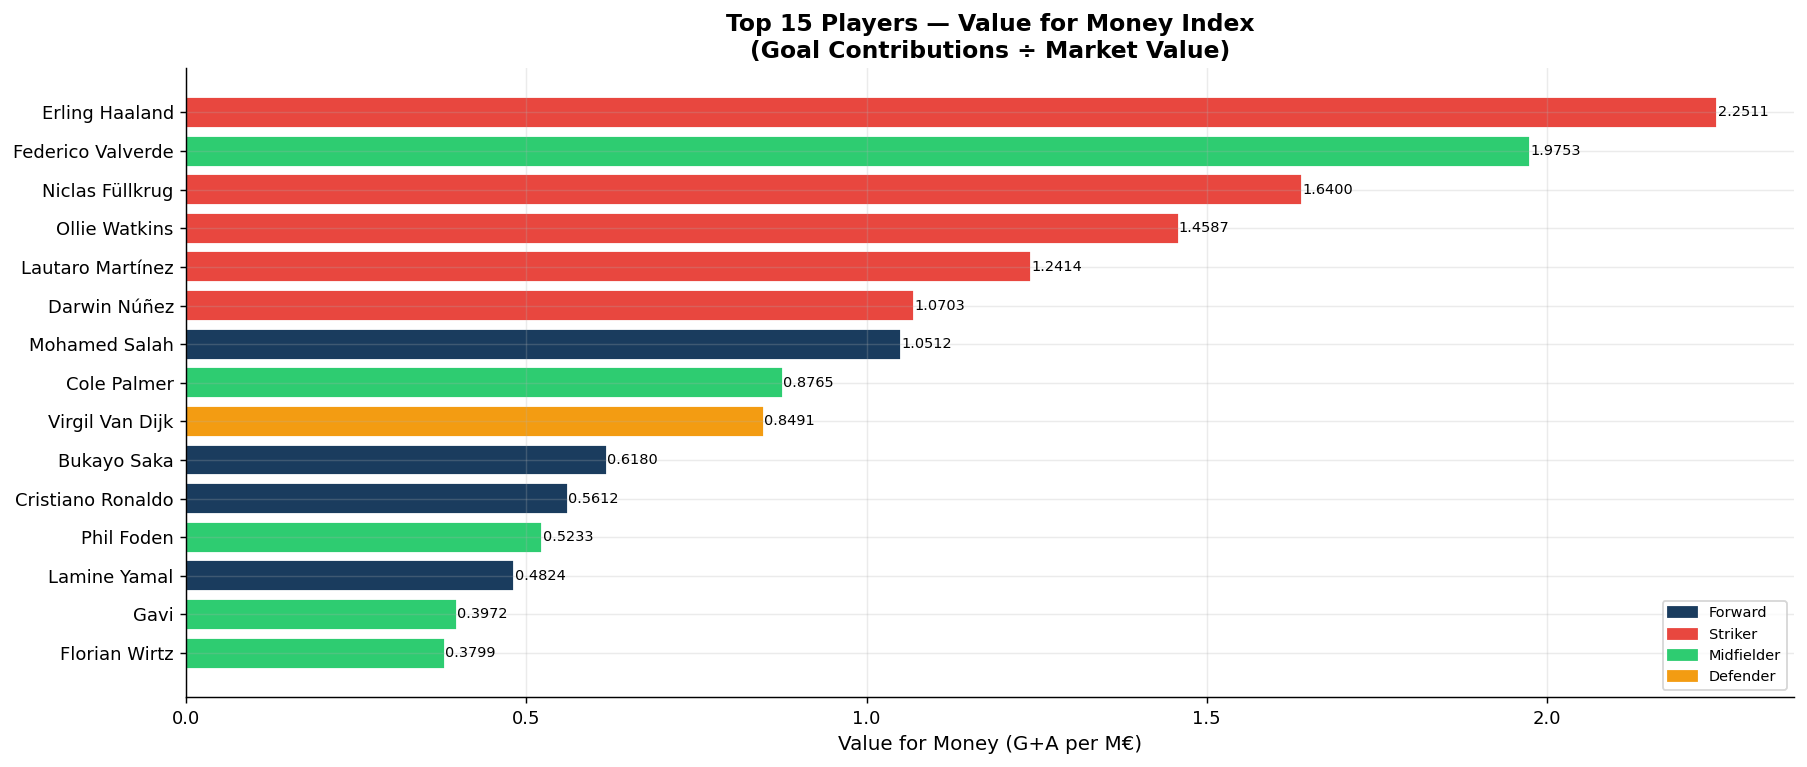

In [35]:
fig, ax = plt.subplots(figsize=(14, 6))

top_vfm = df.nlargest(15, 'value_for_money')[['player_name','value_for_money','position']].reset_index(drop=True)
colors = [pos_colors.get(p, 'grey') for p in top_vfm['position']]

bars = ax.barh(top_vfm['player_name'][::-1], top_vfm['value_for_money'][::-1],
               color=colors[::-1], edgecolor='white', linewidth=1)

for bar in bars:
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=8)

# Legend
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in pos_colors.items()
                  if k in top_vfm['position'].values]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8)

ax.set_title('Top 15 Players — Value for Money Index\n(Goal Contributions ÷ Market Value)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Value for Money (G+A per M€)')

plt.tight_layout()
plt.show()

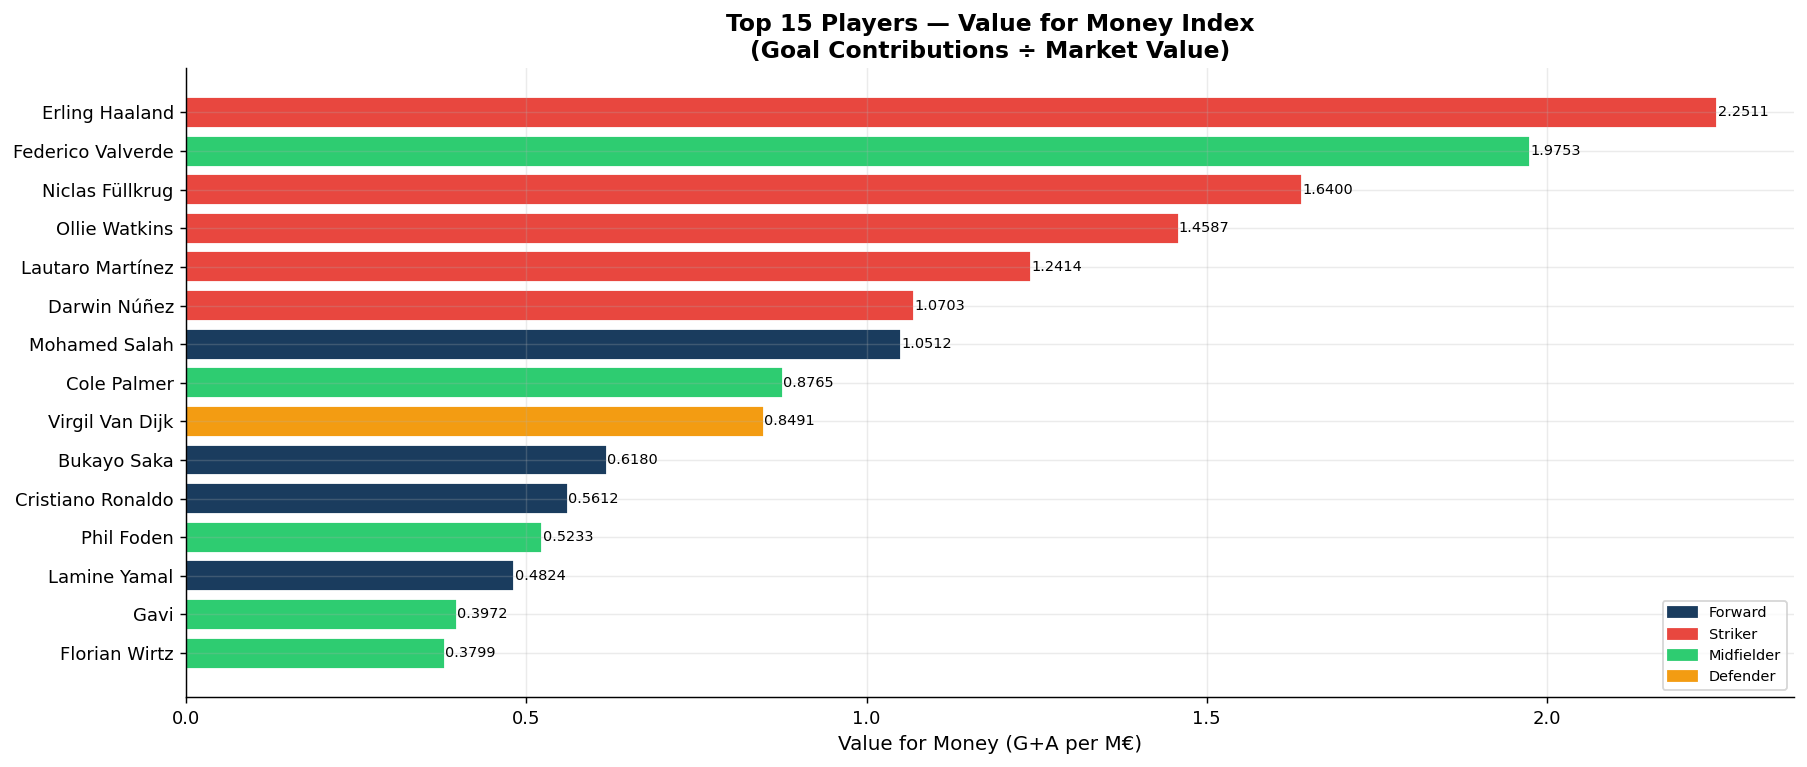

In [47]:
fig, ax = plt.subplots(figsize=(14, 6))

top_vfm = df.nlargest(15, 'value_for_money')[['player_name','value_for_money','position']].reset_index(drop=True)
colors = [pos_colors.get(p, 'grey') for p in top_vfm['position']]

bars = ax.barh(top_vfm['player_name'][::-1], top_vfm['value_for_money'][::-1],
               color=colors[::-1], edgecolor='white', linewidth=1)

for bar in bars:
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=8)

# Legend
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in pos_colors.items()
                  if k in top_vfm['position'].values]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8)

ax.set_title('Top 15 Players — Value for Money Index\n(Goal Contributions ÷ Market Value)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Value for Money (G+A per M€)')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'value_for_money_analysis.png'))
plt.show()

### 6.5 Age vs Performance — Heatmap Density

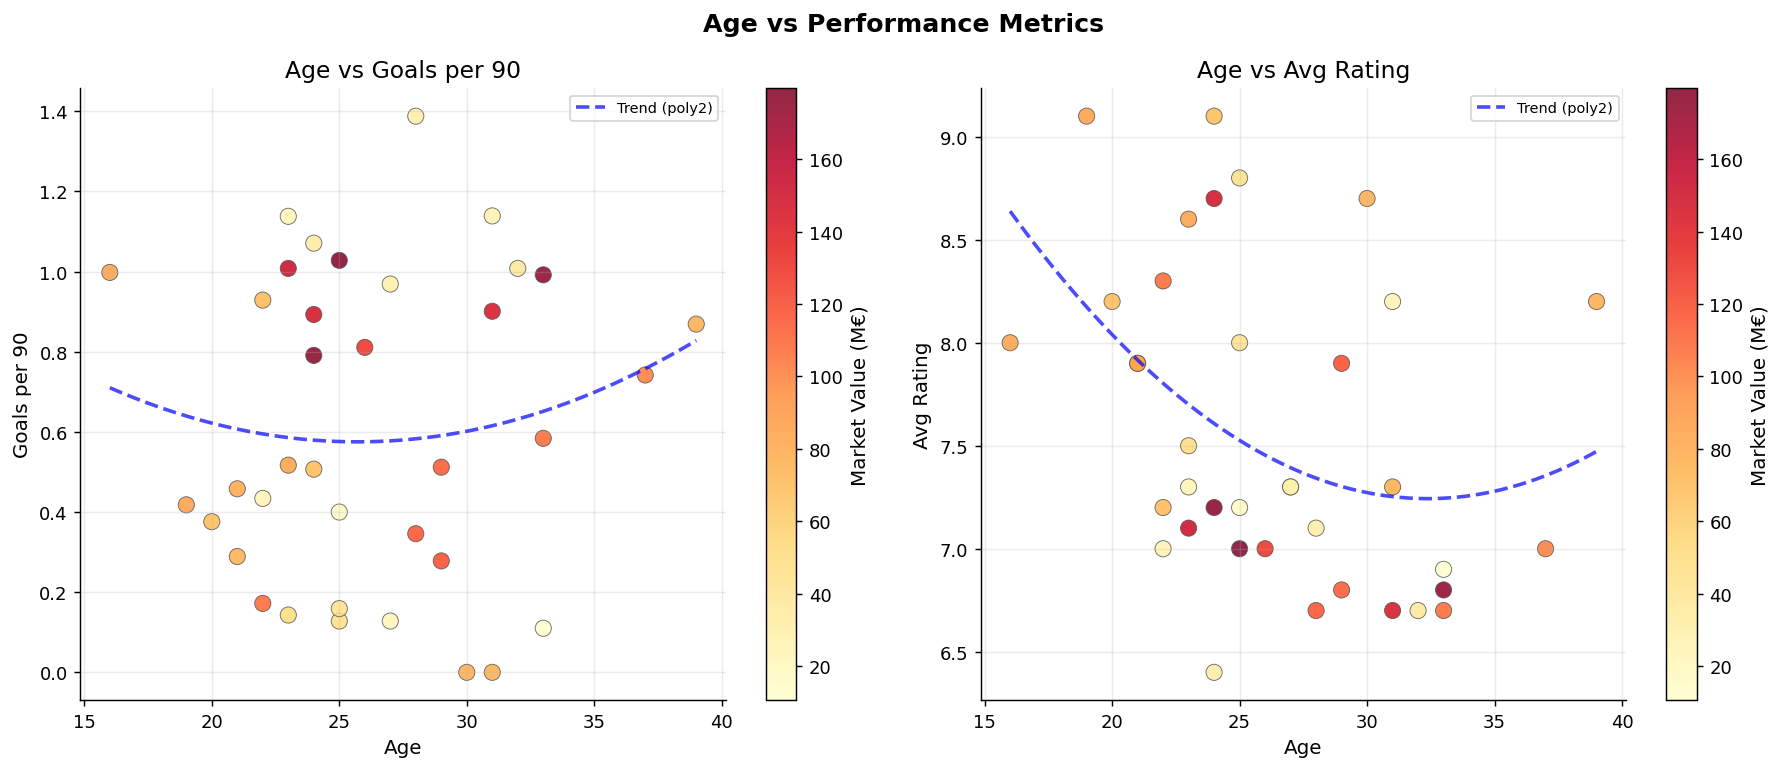

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Age vs Performance Metrics', fontsize=14, fontweight='bold')

for ax, (ycol, ylabel) in zip(axes, [('goals_p90','Goals per 90'), ('avg_rating','Avg Rating')]):
    scatter = ax.scatter(
        df['age'], df[ycol],
        c=df['market_value_m_eur'],
        cmap='YlOrRd',
        s=80, alpha=0.85,
        edgecolors='#555', linewidth=0.5
    )
    plt.colorbar(scatter, ax=ax, label='Market Value (M€)')
    # Smooth trend
    z = np.polyfit(df['age'].dropna(), df[ycol].dropna(), 2)
    p = np.poly1d(z)
    xp = np.linspace(df['age'].min(), df['age'].max(), 100)
    ax.plot(xp, p(xp), 'b--', linewidth=2, alpha=0.7, label='Trend (poly2)')
    ax.set_xlabel('Age')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Age vs {ylabel}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

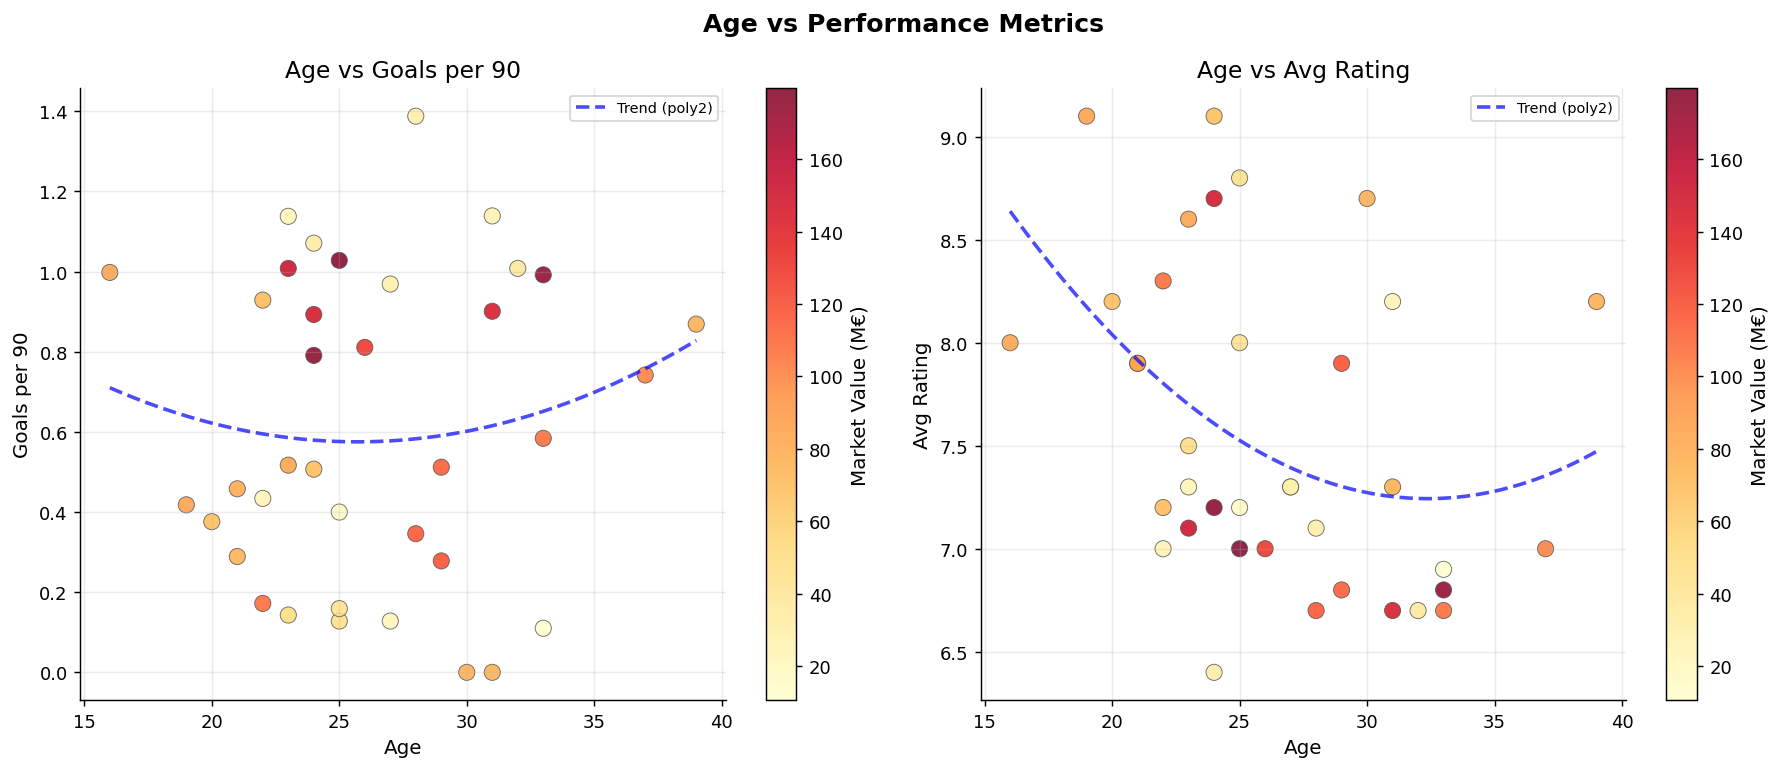

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Age vs Performance Metrics', fontsize=14, fontweight='bold')

for ax, (ycol, ylabel) in zip(axes, [('goals_p90','Goals per 90'), ('avg_rating','Avg Rating')]):
    scatter = ax.scatter(
        df['age'], df[ycol],
        c=df['market_value_m_eur'],
        cmap='YlOrRd',
        s=80, alpha=0.85,
        edgecolors='#555', linewidth=0.5
    )
    plt.colorbar(scatter, ax=ax, label='Market Value (M€)')
    # Smooth trend
    z = np.polyfit(df['age'].dropna(), df[ycol].dropna(), 2)
    p = np.poly1d(z)
    xp = np.linspace(df['age'].min(), df['age'].max(), 100)
    ax.plot(xp, p(xp), 'b--', linewidth=2, alpha=0.7, label='Trend (poly2)')
    ax.set_xlabel('Age')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Age vs {ylabel}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'age_vs_performance_metrics.png'))
plt.show()

---
## 7 · Pipeline Summary

| Stage | Key Actions | Rows (start → end) |
|-------|-------------|--------------------|
| Raw ingestion | Read Excel, skip title row, set header | ~50 raw rows |
| Metadata removal | Drop `Source:` / `Notes:` trailing rows | → ~43 |
| Blank rows | Drop fully null rows | → ~42 |
| Column names | Strip whitespace, unify to `snake_case` | — |
| Duplicates | Remove exact + name-variant dupes | → ~40 |
| Type coercion | All numeric columns → float/int | — |
| Outliers | Cap Shots at 99th pct; fix negative Goals | — |
| Missing values | Median imputation per position group | — |
| Feature engineering | 12 derived metrics (p90, efficiency, VfM) | — |
| EDA + Viz | 6 chart groups, correlation matrix, radar | ✅ |

**Final clean dataset shape:**

In [37]:
print(f'Players: {len(df)} | Columns: {len(df.columns)}')
print(f'Null count: {df.isnull().sum().sum()}')
print('\nFinal column list:')
for c in df.columns:
    print(f'  • {c}')

Players: 37 | Columns: 35
Null count: 9

Final column list:
  • player_name
  • nationality
  • position
  • club
  • age
  • height_m
  • weight_kg
  • apps
  • goals
  • assists
  • shots
  • shotsontarget
  • passes_total
  • pass_accuracy_pct
  • dribbles
  • tackles
  • interceptions
  • yellow_cards
  • red_cards
  • minutes_played
  • avg_rating
  • market_value_m_eur
  • weekly_wage_k_eur
  • 90s_played
  • goals_p90
  • assists_p90
  • shots_p90
  • goal_conversion_pct
  • shot_accuracy_pct
  • goal_contribution
  • goal_contribution_p90
  • defensive_actions
  • defensive_actions_p90
  • discipline_score
  • value_for_money


In [38]:
# Export clean dataset
df.to_csv('football_players_CLEAN.csv', index=False)
print('Clean dataset saved to football_players_CLEAN.csv')

Clean dataset saved to football_players_CLEAN.csv
